# import libs


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
import plotly.express as px
import holidays
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.formula.api import glm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from keras import Sequential
from keras import layers
from keras.models import Model
from keras.layers import LSTM, BatchNormalization, Dropout, Dense, Flatten, Conv1D
from keras.layers import MaxPooling1D, GRU, Input,Masking, Concatenate, dot
from keras.optimizers import Adam, SGD
from keras.losses import MeanAbsoluteError
from keras.metrics import RootMeanSquaredError
from keras.callbacks import EarlyStopping
from keras.callbacks import LearningRateScheduler
import xgboost as xgb
import tensorflow as tf
import tensorflow_addons as tfa
import shap

/Users/khang/anaconda3/envs/my_env/lib/python3.8/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
import nbimporter
%run -i Common_Functions.ipynb
from Common_Functions import *

In [4]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import matplotlib.pyplot as plt
from colorama import Fore

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.layers import LSTM, Dense, Dropout, Input, LayerNormalization, Multiply, Concatenate, Permute, RepeatVector, Lambda
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from keras import backend as K

# load data and split

In [5]:
df_scada_price_qld = pd.read_csv('non_demand_price_scada_hourly.csv', index_col = False)

In [6]:
df_scada_price_qld.head()

,Date_Hour,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,RRP,Hour,Month,WeekDay,Year
0,2019-01-01 00:00:00,0.0,0.0,62858.98551,0.0,0.0,0.0,3975.97976,6.171,0.0,746.831214,1681.9350,1085.28027,64.605948,0,1,1,2019
1,2019-01-01 01:00:00,0.0,0.0,67183.38066,0.0,0.0,0.0,4304.76559,6.732,0.0,669.637499,1834.1200,1416.38041,66.544864,1,1,1,2019
2,2019-01-01 02:00:00,0.0,0.0,65502.50779,0.0,0.0,0.0,4109.34554,6.732,0.0,896.243756,1829.3100,1539.30137,61.140174,2,1,1,2019
3,2019-01-01 03:00:00,0.0,0.0,63496.45470,0.0,0.0,0.0,4091.15064,6.732,0.0,930.731348,1829.7750,1581.81376,52.883149,3,1,1,2019
4,2019-01-01 04:00:00,0.0,0.0,61761.28180,0.0,0.0,0.0,4096.64811,6.732,0.0,902.593736,1832.4225,1613.19730,49.505579,4,1,1,2019


In [6]:
N_SPLITS = 3

X = df_scada_price_qld['Date_Hour']
y = df_scada_price_qld['RRP']

folds = TimeSeriesSplit(n_splits=N_SPLITS)

# ARIMA

No frequency information was provided, so inferred frequency H will be used.
No frequency information was provided, so inferred frequency H will be used.
No frequency information was provided, so inferred frequency H will be used.


MAE: 113.49
RMSE: 325.03


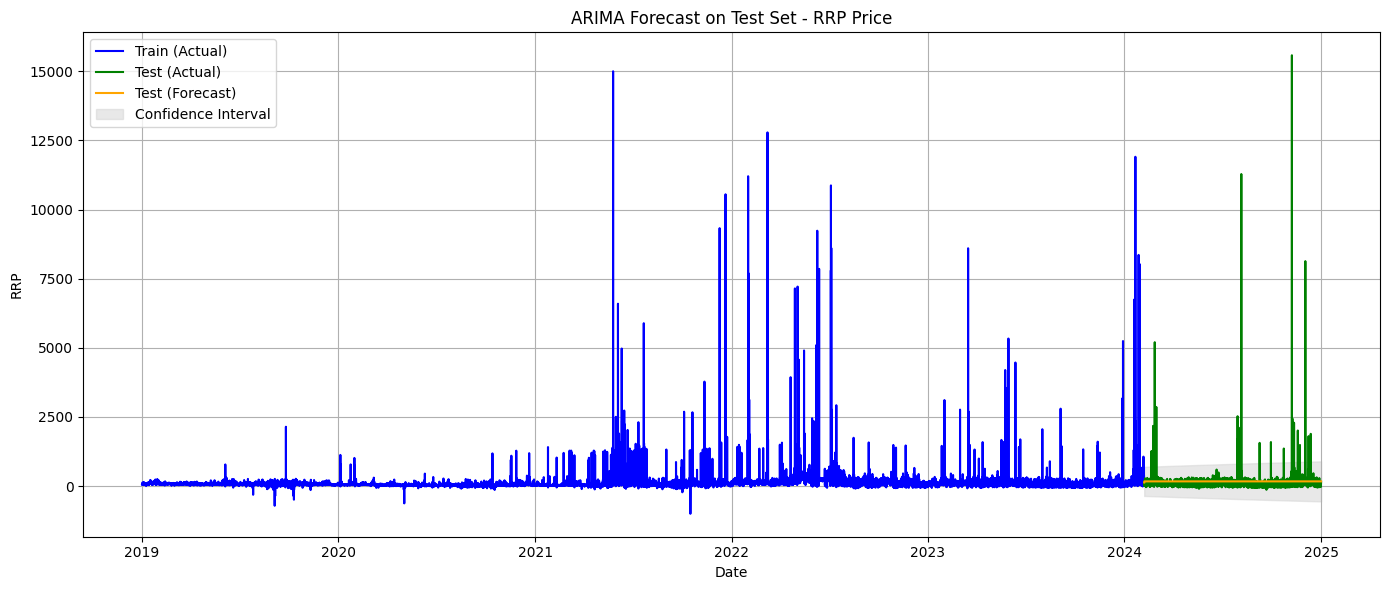

In [35]:
# Convert to time series format with datetime index
series = pd.Series(y.values, index=pd.to_datetime(X))

# Step 2: Train/Test split
train_size = int(0.85 * len(series))
y_train, y_valid = series[:train_size], series[train_size:]

# Step 3: Fit ARIMA on training data
model = ARIMA(y_train, order=(1, 1, 1))  # You can tune (p,d,q)
model_fit = model.fit()

# Step 4: Forecast for test set length
forecast_steps = len(y_valid)
forecast_obj = model_fit.get_forecast(steps=forecast_steps)
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Step 5: Evaluation
mae = mean_absolute_error(y_valid, y_pred)
rmse = math.sqrt(mean_squared_error(y_valid, y_pred))
print(Fore.GREEN + f'MAE: {mae:.2f}')
print(Fore.GREEN + f'RMSE: {rmse:.2f}')

# Step 6: Plot
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Train (Actual)', color='blue')
plt.plot(y_valid.index, y_valid, label='Test (Actual)', color='green')
plt.plot(y_valid.index, y_pred, label='Test (Forecast)', color='orange')
plt.fill_between(y_valid.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='lightgray', alpha=0.5, label='Confidence Interval')
plt.title("ARIMA Forecast on Test Set - RRP Price")
plt.xlabel("Date")
plt.ylabel("RRP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# price - no future - LSTM

In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense, LSTM
from colorama import Fore
import warnings
warnings.filterwarnings('ignore')

# Step 1: Prepare data - aggregate hourly to daily
# Assuming df_scada_price_qld has columns 'Date_Hour' and 'RRP'
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['RRP'].mean().reset_index()
daily_rrp.columns = ['ds', 'y']

# Step 2: Scale data (-1 to 0 scaling is unusual, changing to 0-1)
data = daily_rrp.filter(['y'])
dataset = data.values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Step 3: Train/test split (using 80% for training)
train_size = int(0.8 * len(daily_rrp))
test_size = len(daily_rrp) - train_size

# Using 30 days lookback (about 1 month)
look_back = 30  

train = scaled_data[:train_size, :]
test = scaled_data[train_size - look_back:, :]  # Include lookback window in test

# Step 4: Create windowed datasets
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i - look_back:i, 0])
        Y.append(dataset[i, 0])
    return np.array(X), np.array(Y)

x_train, y_train = create_dataset(train, look_back)
x_test, y_test = create_dataset(test, look_back)

# Reshape to [samples, time steps, features]
x_train = np.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
x_test = np.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1]))

# Step 5: Build and train LSTM (simplified architecture)
model = Sequential()
model.add(LSTM(50, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Added early stopping to prevent overfitting
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(x_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(x_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)

# Step 6: Predictions & inverse scaling
train_predict = model.predict(x_train)
test_predict = model.predict(x_test)

train_predict_inv = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict_inv = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 7: Evaluation
score_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict_inv))
score_mae = mean_absolute_error(y_test_inv, test_predict_inv)
print(Fore.GREEN + 'RMSE: {:.2f}'.format(score_rmse))
print(Fore.GREEN + 'MAE: {:.2f}'.format(score_mae))

Epoch 1/50
54/54 [==============================] - 1s 4ms/step - loss: 0.0039 - val_loss: 0.0042
Epoch 2/50
54/54 [==============================] - 0s 840us/step - loss: 0.0029 - val_loss: 0.0039
Epoch 3/50
54/54 [==============================] - 0s 752us/step - loss: 0.0029 - val_loss: 0.0038
Epoch 4/50
54/54 [==============================] - 0s 744us/step - loss: 0.0027 - val_loss: 0.0038
Epoch 5/50
54/54 [==============================] - 0s 736us/step - loss: 0.0027 - val_loss: 0.0038
Epoch 6/50
54/54 [==============================] - 0s 755us/step - loss: 0.0026 - val_loss: 0.0040
Epoch 7/50
54/54 [==============================] - 0s 733us/step - loss: 0.0027 - val_loss: 0.0038
Epoch 8/50
54/54 [==============================] - 0s 731us/step - loss: 0.0026 - val_loss: 0.0038
Epoch 9/50
54/54 [==============================] - 0s 731us/step - loss: 0.0025 - val_loss: 0.0038
Epoch 10/50
54/54 [==============================] - 0s 714us/step - loss: 0.0026 - val_loss: 0.0038
E

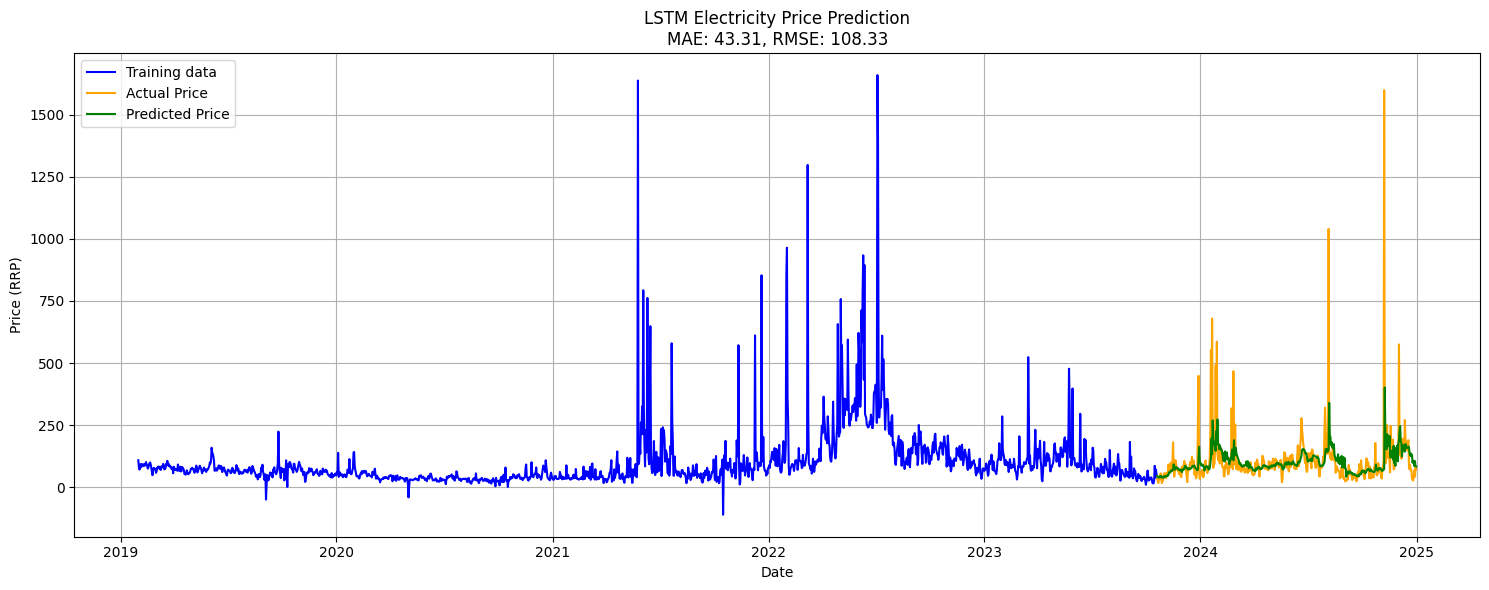

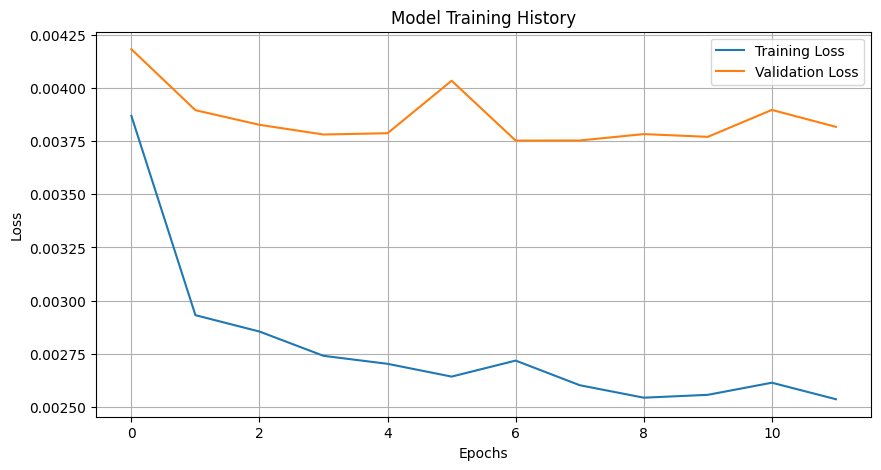

In [48]:
# Step 8: Plotting
# Prepare dates for plotting
train_dates = daily_rrp.iloc[look_back:train_size]['ds']
test_dates = daily_rrp.iloc[train_size:train_size + len(test_predict_inv)]['ds']

plt.figure(figsize=(15, 6))
plt.plot(train_dates, y_train_inv, label='Training data', color='blue')
plt.plot(test_dates, y_test_inv, label='Actual Price', color='orange')
plt.plot(test_dates, test_predict_inv, label='Predicted Price', color='green')

plt.title(f'LSTM Electricity Price Prediction\nMAE: {score_mae:.2f}, RMSE: {score_rmse:.2f}')
plt.xlabel('Date')
plt.ylabel('Price (RRP)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# solar generation - no future - improved LSTM 

In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from statsmodels.tsa.seasonal import seasonal_decompose

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# 2. Time-based split (70%/15%/15%)
train_end = int(0.7 * len(daily_rrp))
val_end = train_end + int(0.15 * len(daily_rrp))

train = daily_rrp.iloc[:train_end]
val = daily_rrp.iloc[train_end- look_back:val_end]
test = daily_rrp.iloc[val_end- look_back:]

# 3. Feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_month'] = df['ds'].dt.day
    df['month'] = df['ds'].dt.month
    return df

train = add_features(train)
val = add_features(val)
test = add_features(test)

# 4. Scaling (fit only on train)
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train[['y']])
val_scaled = scaler.transform(val[['y']])
test_scaled = scaler.transform(test[['y']])

# 5. Create sequences
look_back = 60

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, look_back)
X_val, y_val = create_sequences(val_scaled, look_back) 
X_test, y_test = create_sequences(test_scaled, look_back)

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 6. Build model
model = Sequential([
    LSTM(64, input_shape=(look_back, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 7. Train with validation
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

# 8. Evaluate on test set
test_pred = model.predict(X_test)
test_pred_inv = scaler.inverse_transform(test_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# 9. Calculate metrics
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, mse, rmse, mape

mae, mse, rmse, mape = calculate_metrics(y_test_inv, test_pred_inv)

print(f"""
Test Set Metrics:
MAE: {mae:.2f}
MSE: {mse:.2f} 
RMSE: {rmse:.2f}
MAPE: {mape:.2f}%
""")

Epoch 1/50
47/47 [==============================] - 2s 21ms/step - loss: 0.2897 - val_loss: 0.6012
Epoch 2/50
47/47 [==============================] - 1s 15ms/step - loss: 0.2591 - val_loss: 0.6914
Epoch 3/50
47/47 [==============================] - 1s 16ms/step - loss: 0.2610 - val_loss: 0.6113
Epoch 4/50
47/47 [==============================] - 1s 16ms/step - loss: 0.2417 - val_loss: 0.5575
Epoch 5/50
47/47 [==============================] - 1s 16ms/step - loss: 0.2281 - val_loss: 0.5333
Epoch 6/50
47/47 [==============================] - 1s 16ms/step - loss: 0.2204 - val_loss: 0.5239
Epoch 7/50
47/47 [==============================] - 1s 16ms/step - loss: 0.2105 - val_loss: 0.5020
Epoch 8/50
47/47 [==============================] - 1s 16ms/step - loss: 0.2070 - val_loss: 0.5206
Epoch 9/50
47/47 [==============================] - 1s 16ms/step - loss: 0.1935 - val_loss: 0.4585
Epoch 10/50
47/47 [==============================] - 1s 16ms/step - loss: 0.1904 - val_loss: 0.4534
Epoch 11/

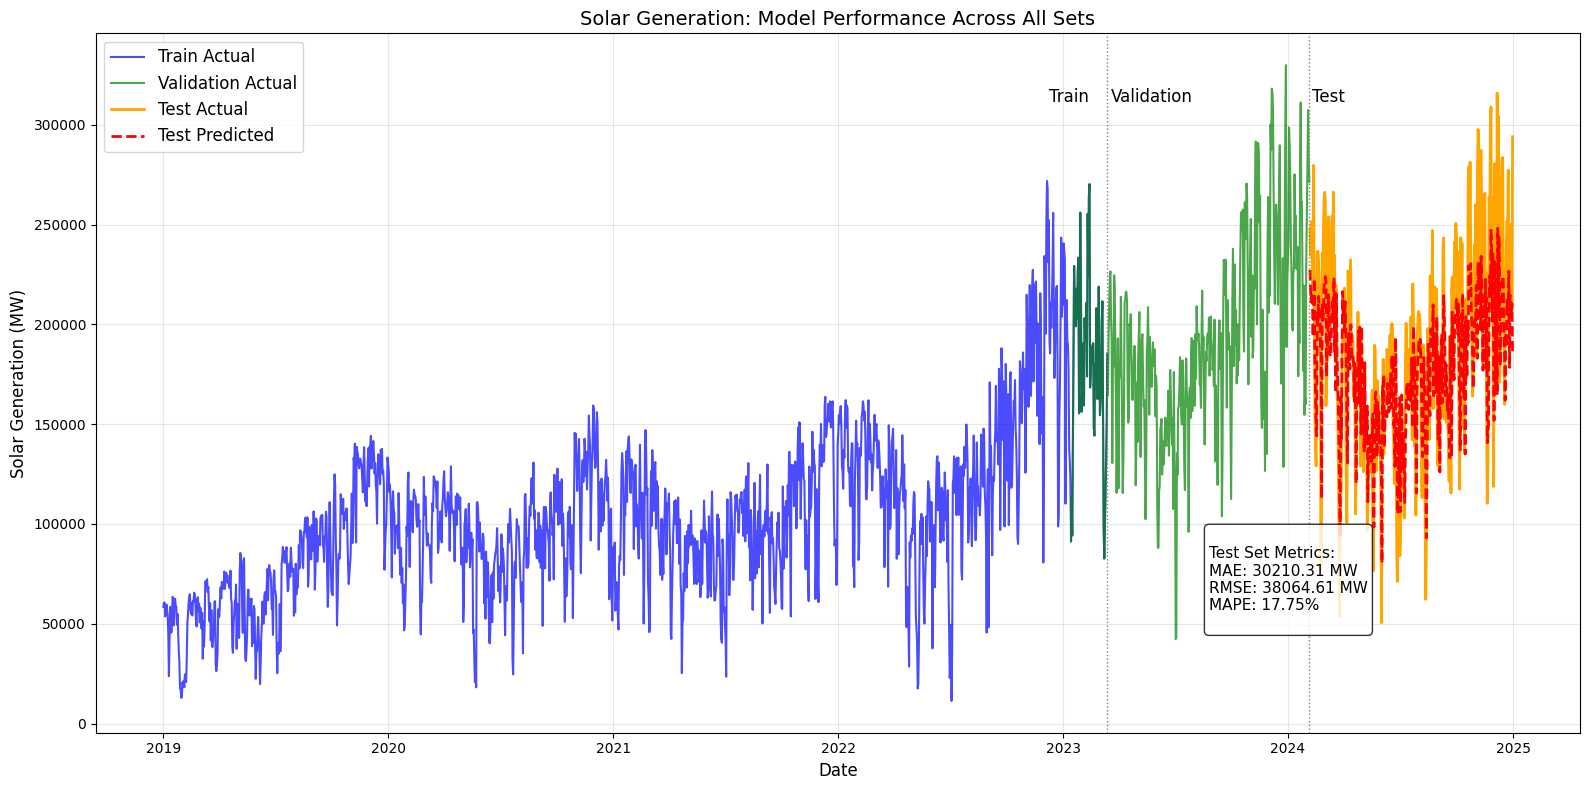

In [36]:
plt.figure(figsize=(16, 8))

# Plot training data
plt.plot(train['ds'], train['y'], label='Train Actual', color='blue', alpha=0.7)

# Plot validation data
plt.plot(val['ds'], val['y'], label='Validation Actual', color='green', alpha=0.7)

# Plot test actual vs predicted
plt.plot(test['ds'].iloc[look_back:], y_test_inv, 
         label='Test Actual', color='orange', linewidth=2)
plt.plot(test['ds'].iloc[look_back:], test_pred_inv, 
         label='Test Predicted', color='red', linestyle='--', linewidth=2)

# Add vertical separators
train_end_date = train['ds'].iloc[-1]
val_end_date = val['ds'].iloc[-1]
plt.axvline(x=train_end_date, color='gray', linestyle=':', linewidth=1)
plt.axvline(x=val_end_date, color='gray', linestyle=':', linewidth=1)

# Add region labels
plt.text(train_end_date - pd.Timedelta(days=30), plt.ylim()[1]*0.9, 
         'Train', ha='right', fontsize=12)
plt.text(train_end_date + pd.Timedelta(days=5), plt.ylim()[1]*0.9, 
         'Validation', ha='left', fontsize=12)
plt.text(val_end_date + pd.Timedelta(days=5), plt.ylim()[1]*0.9, 
         'Test', ha='left', fontsize=12)

# Formatting
plt.title('Solar Generation: Model Performance Across All Sets', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Solar Generation (MW)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)

# Add metrics box
metrics_text = f"""
Test Set Metrics:
MAE: {mae:.2f} MW
RMSE: {rmse:.2f} MW
MAPE: {mape:.2f}%
"""
plt.annotate(metrics_text, xy=(0.75, 0.15), xycoords='axes fraction',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             fontsize=11)

plt.tight_layout()
plt.show()

# solar generation - next 1 year - improved LSTM

In [76]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from statsmodels.tsa.seasonal import seasonal_decompose

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # ⭐️ New trend feature ⭐️
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df

# 3. Time-based split
val_start = '2024-11-01'
test_start = '2025-01-01'

train_end_idx = daily_rrp[daily_rrp['ds'] < val_start].index[-1]
val_end_idx = daily_rrp[daily_rrp['ds'] < test_start].index[-1]

train = daily_rrp.iloc[:train_end_idx + 1]
val = daily_rrp.iloc[train_end_idx - look_back + 1:val_end_idx + 1] 

# Create future test set with all features
test_future = pd.DataFrame({'ds': pd.date_range(test_start, '2025-12-31')})
test_future = add_features(test_future)
test_future['y'] = 0  # Placeholder

# Add features to all sets
train = add_features(train)
val = add_features(val)

# 4. Scaling - separate scalers for y and features
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_features_scaled = feature_scaler.transform(test_future.drop(columns=['ds', 'y']))

# 5. Create sequences with all features
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y for training
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

# 6. Build model with multiple features
n_features = X_train.shape[2]  # y + other features

model = Sequential([
    LSTM(128, input_shape=(look_back, n_features), return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# 7. Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

# 8. Predict future with all features
def predict_future(model, last_sequence, future_features, look_back):
    predictions = []
    current_seq = last_sequence.copy()
    
    for i in range(len(future_features)):
        # Prepare input with features
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # Update sequence with new prediction and corresponding features
        new_row = np.hstack([[pred], future_features[i]])
        current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions)

# Get last sequence from validation
last_sequence = val_combined[-look_back:]

# Make predictions
future_pred_scaled = predict_future(model, last_sequence, test_features_scaled, look_back)
future_pred = y_scaler.inverse_transform(future_pred_scaled.reshape(-1, 1)).flatten()

Epoch 1/100
65/65 [==============================] - 4s 42ms/step - loss: 0.2024 - val_loss: 0.4447 - lr: 0.0010
Epoch 2/100
65/65 [==============================] - 2s 38ms/step - loss: 0.1765 - val_loss: 0.4481 - lr: 0.0010
Epoch 3/100
65/65 [==============================] - 2s 38ms/step - loss: 0.1660 - val_loss: 0.4813 - lr: 0.0010
Epoch 4/100
65/65 [==============================] - 2s 38ms/step - loss: 0.1568 - val_loss: 0.4550 - lr: 0.0010
Epoch 5/100
65/65 [==============================] - 2s 37ms/step - loss: 0.1533 - val_loss: 0.4361 - lr: 0.0010
Epoch 6/100
65/65 [==============================] - 2s 38ms/step - loss: 0.1424 - val_loss: 0.4252 - lr: 0.0010
Epoch 7/100
65/65 [==============================] - 2s 38ms/step - loss: 0.1394 - val_loss: 0.4000 - lr: 0.0010
Epoch 8/100
65/65 [==============================] - 2s 38ms/step - loss: 0.1297 - val_loss: 0.3791 - lr: 0.0010
Epoch 9/100
65/65 [==============================] - 2s 37ms/step - loss: 0.1238 - val_loss: 0.4

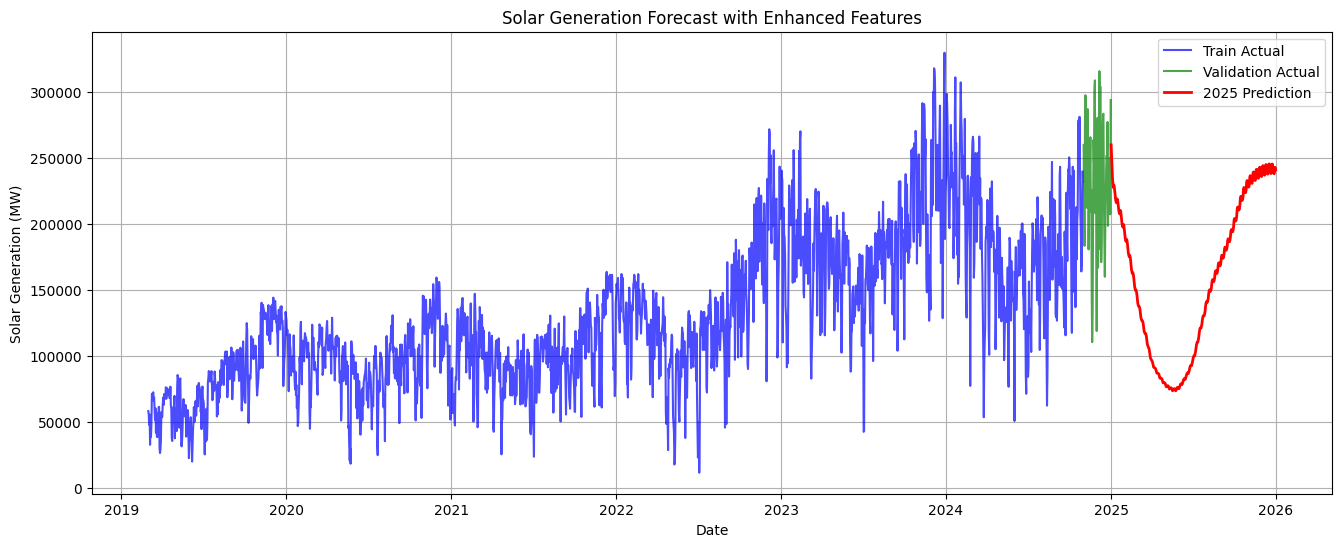

Prediction range: 73396-260016 MW
Seasonal variation: 117.5%


In [77]:
plt.figure(figsize=(16,6))

# Plot training actual
plt.plot(train['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(train_y_scaled[look_back:]), 
         label='Train Actual', color='blue', alpha=0.7)

# Plot validation actual
plt.plot(val['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(val_y_scaled[look_back:]), 
         label='Validation Actual', color='green', alpha=0.7)

# Plot predictions with seasonal pattern
plt.plot(test_future['ds'], future_pred, 
         label='2025 Prediction', color='red', linewidth=2)

plt.title('Solar Generation Forecast with Enhanced Features')
plt.xlabel('Date')
plt.ylabel('Solar Generation (MW)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Prediction range: {future_pred.min():.0f}-{future_pred.max():.0f} MW")
print(f"Seasonal variation: {(future_pred.max() - future_pred.min())/future_pred.mean()*100:.1f}%")

# solar generation - next 3 years - improved LSTM

In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from statsmodels.tsa.seasonal import seasonal_decompose

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # ⭐️ New trend feature ⭐️
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df


# 3. Time-based split
val_start = '2024-11-01'
test_start = '2025-01-01'

train_end_idx = daily_rrp[daily_rrp['ds'] < val_start].index[-1]
val_end_idx = daily_rrp[daily_rrp['ds'] < test_start].index[-1]

train = daily_rrp.iloc[:train_end_idx + 1]
val = daily_rrp.iloc[train_end_idx - look_back + 1:val_end_idx + 1] 

# Create future test set with all features
test_future = pd.DataFrame({'ds': pd.date_range(test_start, '2027-12-31')})
test_future = add_features(test_future)
test_future['y'] = 0  # Placeholder

# Add features to all sets
train = add_features(train)
val = add_features(val)

# 4. Scaling - separate scalers for y and features
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_features_scaled = feature_scaler.transform(test_future.drop(columns=['ds', 'y']))

# 5. Create sequences with all features
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y for training
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

# 6. Build model with multiple features
n_features = X_train.shape[2]  # y + other features

model = Sequential([
    LSTM(128, input_shape=(look_back, n_features), return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])


optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# 7. Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

# 8. Predict future with all features
def predict_future(model, last_sequence, future_features, look_back):
    predictions = []
    current_seq = last_sequence.copy()
    
    for i in range(len(future_features)):
        # Prepare input with features
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # Update sequence with new prediction and corresponding features
        new_row = np.hstack([[pred], future_features[i]])
        current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions)

# Get last sequence from validation
last_sequence = val_combined[-look_back:]

# Make predictions
future_pred_scaled = predict_future(model, last_sequence, test_features_scaled, look_back)
future_pred = y_scaler.inverse_transform(future_pred_scaled.reshape(-1, 1)).flatten()

Epoch 1/100
65/65 [==============================] - 5s 50ms/step - loss: 0.2133 - val_loss: 0.5462 - lr: 0.0010
Epoch 2/100
65/65 [==============================] - 3s 45ms/step - loss: 0.1893 - val_loss: 0.4575 - lr: 0.0010
Epoch 3/100
65/65 [==============================] - 3s 45ms/step - loss: 0.1813 - val_loss: 0.5203 - lr: 0.0010
Epoch 4/100
65/65 [==============================] - 3s 45ms/step - loss: 0.1742 - val_loss: 0.5129 - lr: 0.0010
Epoch 5/100
65/65 [==============================] - 3s 46ms/step - loss: 0.1735 - val_loss: 0.4588 - lr: 0.0010
Epoch 6/100
65/65 [==============================] - 3s 46ms/step - loss: 0.1684 - val_loss: 0.4419 - lr: 0.0010
Epoch 7/100
65/65 [==============================] - 3s 46ms/step - loss: 0.1730 - val_loss: 0.4336 - lr: 0.0010
Epoch 8/100
65/65 [==============================] - 3s 46ms/step - loss: 0.1671 - val_loss: 0.4271 - lr: 0.0010
Epoch 9/100
65/65 [==============================] - 3s 45ms/step - loss: 0.1612 - val_loss: 0.4

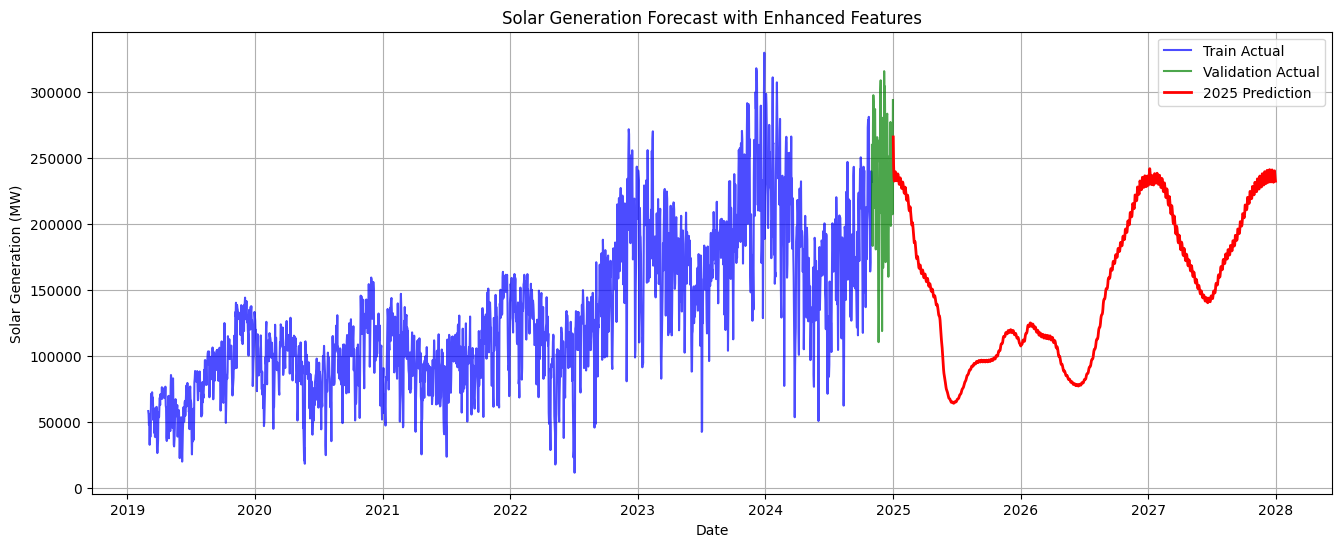

Prediction range: 63993-265982 MW
Seasonal variation: 132.0%


In [80]:
plt.figure(figsize=(16,6))

# Plot training actual
plt.plot(train['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(train_y_scaled[look_back:]), 
         label='Train Actual', color='blue', alpha=0.7)

# Plot validation actual
plt.plot(val['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(val_y_scaled[look_back:]), 
         label='Validation Actual', color='green', alpha=0.7)

# Plot predictions with seasonal pattern
plt.plot(test_future['ds'], future_pred, 
         label='2025 Prediction', color='red', linewidth=2)

plt.title('Solar Generation Forecast with Enhanced Features')
plt.xlabel('Date')
plt.ylabel('Solar Generation (MW)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Prediction range: {future_pred.min():.0f}-{future_pred.max():.0f} MW")
print(f"Seasonal variation: {(future_pred.max() - future_pred.min())/future_pred.mean()*100:.1f}%")

#  solar generation - next 3 years - transformer

In [86]:
from keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Layer, Input
from keras.models import Model

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # ⭐️ New trend feature ⭐️
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df


# 3. Time-based split
val_start = '2024-11-01'
test_start = '2025-01-01'

train_end_idx = daily_rrp[daily_rrp['ds'] < val_start].index[-1]
val_end_idx = daily_rrp[daily_rrp['ds'] < test_start].index[-1]

train = daily_rrp.iloc[:train_end_idx + 1]
val = daily_rrp.iloc[train_end_idx - look_back + 1:val_end_idx + 1] 

# Create future test set with all features
test_future = pd.DataFrame({'ds': pd.date_range(test_start, '2027-12-31')})
test_future = add_features(test_future)
test_future['y'] = 0  # Placeholder

# Add features to all sets
train = add_features(train)
val = add_features(val)

# 4. Scaling - separate scalers for y and features
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_features_scaled = feature_scaler.transform(test_future.drop(columns=['ds', 'y']))

# 5. Create sequences with all features
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y for training
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

# 6. Build model with multiple features
# Custom Transformer Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Define model architecture
input_layer = Input(shape=(look_back, n_features))

x = transformer_encoder(input_layer, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(1)(x[:, -1, :])  # Predict based on the last time step output

transformer_model = Model(inputs=input_layer, outputs=x)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
transformer_model.compile(optimizer=optimizer, loss='mse')

transformer_model.summary()


# 7. Train model
history = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)


# 8. Predict future with all features
def predict_future(model, last_sequence, future_features, look_back):
    predictions = []
    current_seq = last_sequence.copy()
    
    for i in range(len(future_features)):
        # Prepare input with features
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # Update sequence with new prediction and corresponding features
        new_row = np.hstack([[pred], future_features[i]])
        current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions)

# Get last sequence from validation
last_sequence = val_combined[-look_back:]

# Just replace model by transformer_model
future_pred_scaled = predict_future(transformer_model, last_sequence, test_features_scaled, look_back)
future_pred = y_scaler.inverse_transform(future_pred_scaled.reshape(-1, 1)).flatten()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 60, 13)]             0         []                            
                                                                                                  
 multi_head_attention_4 (Mu  (None, 60, 13)               14093     ['input_3[0][0]',             
 ltiHeadAttention)                                                   'input_3[0][0]']             
                                                                                                  
 dropout_69 (Dropout)        (None, 60, 13)               0         ['multi_head_attention_4[0][0]
                                                                    ']                            
                                                                                            

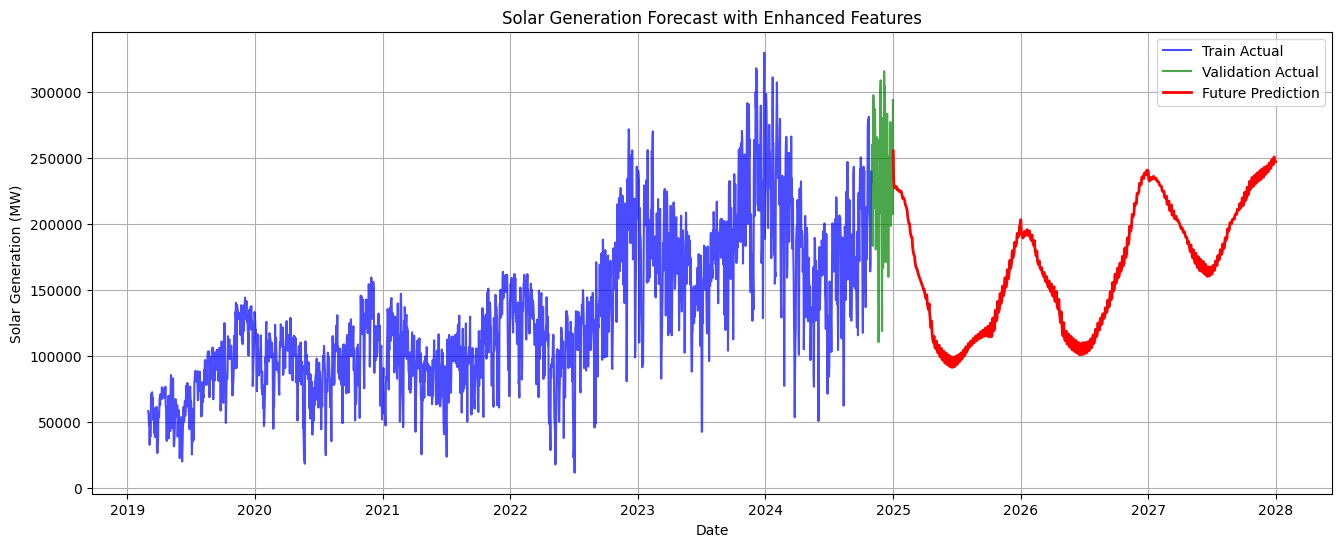

Prediction range: 91237-255483 MW
Seasonal variation: 98.1%


In [87]:
plt.figure(figsize=(16,6))

# Plot training actual
plt.plot(train['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(train_y_scaled[look_back:]), 
         label='Train Actual', color='blue', alpha=0.7)

# Plot validation actual
plt.plot(val['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(val_y_scaled[look_back:]), 
         label='Validation Actual', color='green', alpha=0.7)

# Plot predictions with seasonal pattern
plt.plot(test_future['ds'], future_pred, 
         label='Future Prediction', color='red', linewidth=2)

plt.title('Solar Generation Forecast with Enhanced Features')
plt.xlabel('Date')
plt.ylabel('Solar Generation (MW)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Prediction range: {future_pred.min():.0f}-{future_pred.max():.0f} MW")
print(f"Seasonal variation: {(future_pred.max() - future_pred.min())/future_pred.mean()*100:.1f}%")

# price - next 3 years - transformer

In [23]:
from keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Layer, Input
from keras.models import Model
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from statsmodels.tsa.seasonal import seasonal_decompose

look_back = 60

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['RRP'].mean().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # ⭐️ New trend feature ⭐️
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df


# 3. Time-based split
val_start = '2024-11-01'
test_start = '2025-01-01'

train_end_idx = daily_rrp[daily_rrp['ds'] < val_start].index[-1]
val_end_idx = daily_rrp[daily_rrp['ds'] < test_start].index[-1]

train = daily_rrp.iloc[:train_end_idx + 1]
val = daily_rrp.iloc[train_end_idx - look_back + 1:val_end_idx + 1] 

# Create future test set with all features
test_future = pd.DataFrame({'ds': pd.date_range(test_start, '2027-12-31')})
test_future = add_features(test_future)
test_future['y'] = 0  # Placeholder

# Add features to all sets
train = add_features(train)
val = add_features(val)

# 4. Scaling - separate scalers for y and features
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_features_scaled = feature_scaler.transform(test_future.drop(columns=['ds', 'y']))

# 5. Create sequences with all features
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y for training
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

# 6. Build model with multiple features
# Custom Transformer Block
n_features = X_train.shape[2]
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Define model architecture
input_layer = Input(shape=(look_back, n_features))

x = transformer_encoder(input_layer, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(1)(x[:, -1, :])  # Predict based on the last time step output

transformer_model = Model(inputs=input_layer, outputs=x)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
transformer_model.compile(optimizer=optimizer, loss='mse')

transformer_model.summary()


# 7. Train model
history = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)


# 8. Predict future with all features
def predict_future(model, last_sequence, future_features, look_back):
    predictions = []
    current_seq = last_sequence.copy()
    
    for i in range(len(future_features)):
        # Prepare input with features
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # Update sequence with new prediction and corresponding features
        new_row = np.hstack([[pred], future_features[i]])
        current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions)

# Get last sequence from validation
last_sequence = val_combined[-look_back:]

# Just replace model by transformer_model
future_pred_scaled = predict_future(transformer_model, last_sequence, test_features_scaled, look_back)
future_pred = y_scaler.inverse_transform(future_pred_scaled.reshape(-1, 1)).flatten()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 60, 13)]             0         []                            
                                                                                                  
 multi_head_attention_4 (Mu  (None, 60, 13)               14093     ['input_3[0][0]',             
 ltiHeadAttention)                                                   'input_3[0][0]']             
                                                                                                  
 dropout_8 (Dropout)         (None, 60, 13)               0         ['multi_head_attention_4[0][0]
                                                                    ']                            
                                                                                            

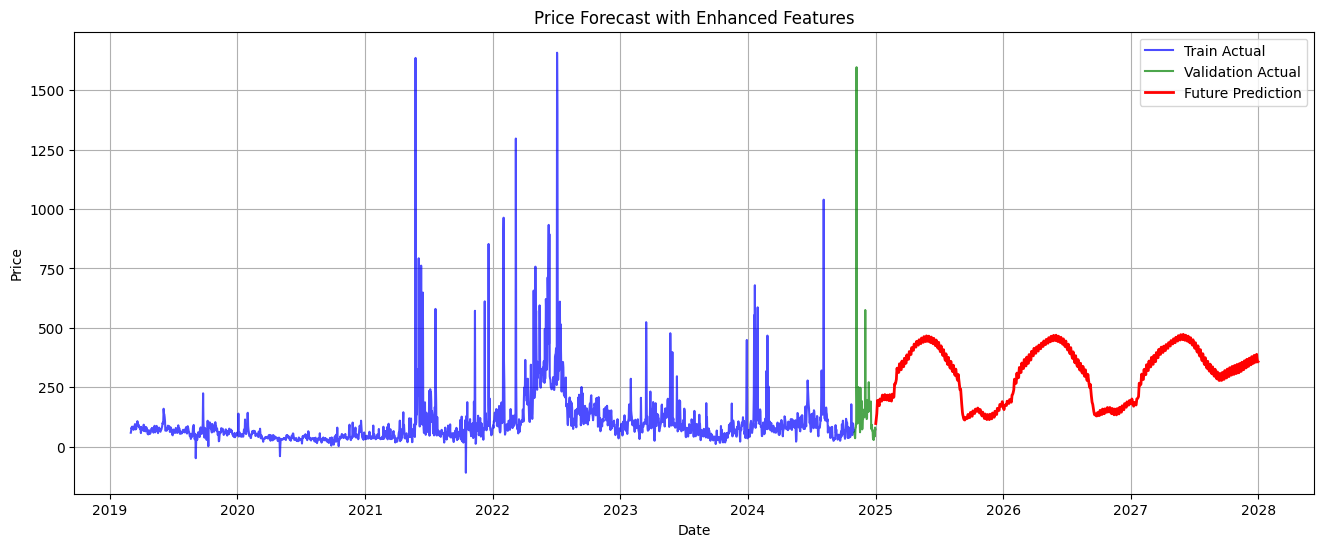

Prediction range: 97-473 MW
Seasonal variation: 122.0%


In [24]:
plt.figure(figsize=(16,6))

# Plot training actual
plt.plot(train['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(train_y_scaled[look_back:]), 
         label='Train Actual', color='blue', alpha=0.7)

# Plot validation actual
plt.plot(val['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(val_y_scaled[look_back:]), 
         label='Validation Actual', color='green', alpha=0.7)

# Plot predictions with seasonal pattern
plt.plot(test_future['ds'], future_pred, 
         label='Future Prediction', color='red', linewidth=2)

plt.title('Price Forecast with Enhanced Features')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

print(f"Prediction range: {future_pred.min():.0f}-{future_pred.max():.0f} MW")
print(f"Seasonal variation: {(future_pred.max() - future_pred.min())/future_pred.mean()*100:.1f}%")

In [29]:
from scipy.stats import ttest_ind

# Prepare DataFrame
n_days = len(future_pred)
dates = pd.date_range('2025-01-01', periods=n_days)

pred_df = pd.DataFrame({'ds': dates, 'y_pred': future_pred})
pred_df['year'] = pred_df['ds'].dt.year
daily_rrp['year'] = daily_rrp['ds'].dt.year

# Set up
results = []

for current_year in [2025, 2026, 2027]:
    # Historical data
    historical = daily_rrp[daily_rrp['year'] < current_year]['y']
    if current_year > 2025:
        previous_year_pred = pred_df[pred_df['year'] == (current_year - 1)]['y_pred']
        historical = pd.concat([historical, previous_year_pred], ignore_index=True)
    
    # Current year data
    current = pred_df[pred_df['year'] == current_year]['y_pred']
    
    # T-test
    t_stat, p_value = ttest_ind(current, historical, equal_var=False)
    
    # Means
    historical_mean = historical.mean()
    current_mean = current.mean()
    
    # Absolute and percentage change
    mean_diff = current_mean - historical_mean
    pct_change = (mean_diff / historical_mean) * 100
    
    results.append({
        'Year': current_year,
        'Historical Mean (MW)': historical_mean,
        'Current Mean (MW)': current_mean,
        'Mean Difference (MW)': mean_diff,
        'Percentage Change (%)': pct_change,
        'T-Statistic': t_stat,
        'P-Value': p_value
    })

# Show results
results_df = pd.DataFrame(results)
print(results_df)

# Interpret results
for idx, row in results_df.iterrows():
    if row['P-Value'] < 0.05:
        print(f"✅ {row['Year']}: Significant INCREASE ({row['Percentage Change (%)']:.2f}% increase, p={row['P-Value']:.4f})")
    else:
        print(f"❌ {row['Year']}: No significant change (p={row['P-Value']:.4f})")


   Year  Historical Mean (MW)  Current Mean (MW)  Mean Difference (MW)  \
0  2025            101.010556         274.627045            173.616489   
1  2026            125.793511         294.489655            168.696144   
2  2027            128.628810         354.131256            225.502446   

   Percentage Change (%)  T-Statistic        P-Value  
0             171.879550    25.229995   2.267335e-90  
1             134.105601    25.205195   1.364666e-91  
2             175.312550    49.370111  1.042163e-248  
✅ 2025.0: Significant INCREASE (171.88% increase, p=0.0000)
✅ 2026.0: Significant INCREASE (134.11% increase, p=0.0000)
✅ 2027.0: Significant INCREASE (175.31% increase, p=0.0000)


# retrain for solar generation - transformer

In [30]:
from keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Layer, Input
from keras.models import Model

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # ⭐️ New trend feature ⭐️
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df


# 3. Time-based split
val_start = '2024-11-01'
test_start = '2025-01-01'

train_end_idx = daily_rrp[daily_rrp['ds'] < val_start].index[-1]
val_end_idx = daily_rrp[daily_rrp['ds'] < test_start].index[-1]

train = daily_rrp.iloc[:train_end_idx + 1]
val = daily_rrp.iloc[train_end_idx - look_back + 1:val_end_idx + 1] 

# Create future test set with all features
test_future = pd.DataFrame({'ds': pd.date_range(test_start, '2027-12-31')})
test_future = add_features(test_future)
test_future['y'] = 0  # Placeholder

# Add features to all sets
train = add_features(train)
val = add_features(val)

# 4. Scaling - separate scalers for y and features
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_features_scaled = feature_scaler.transform(test_future.drop(columns=['ds', 'y']))

# 5. Create sequences with all features
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y for training
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

# 6. Build model with multiple features
# Custom Transformer Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Define model architecture
input_layer = Input(shape=(look_back, n_features))

x = transformer_encoder(input_layer, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(1)(x[:, -1, :])  # Predict based on the last time step output

transformer_model = Model(inputs=input_layer, outputs=x)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
transformer_model.compile(optimizer=optimizer, loss='mse')

transformer_model.summary()


# 7. Train model
history = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)


# 8. Predict future with all features
def predict_future(model, last_sequence, future_features, look_back):
    predictions = []
    current_seq = last_sequence.copy()
    
    for i in range(len(future_features)):
        # Prepare input with features
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # Update sequence with new prediction and corresponding features
        new_row = np.hstack([[pred], future_features[i]])
        current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions)

# Get last sequence from validation
last_sequence = val_combined[-look_back:]

# Just replace model by transformer_model
future_pred_scaled = predict_future(transformer_model, last_sequence, test_features_scaled, look_back)
future_pred = y_scaler.inverse_transform(future_pred_scaled.reshape(-1, 1)).flatten()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 60, 13)]             0         []                            
                                                                                                  
 multi_head_attention_6 (Mu  (None, 60, 13)               14093     ['input_4[0][0]',             
 ltiHeadAttention)                                                   'input_4[0][0]']             
                                                                                                  
 dropout_12 (Dropout)        (None, 60, 13)               0         ['multi_head_attention_6[0][0]
                                                                    ']                            
                                                                                            

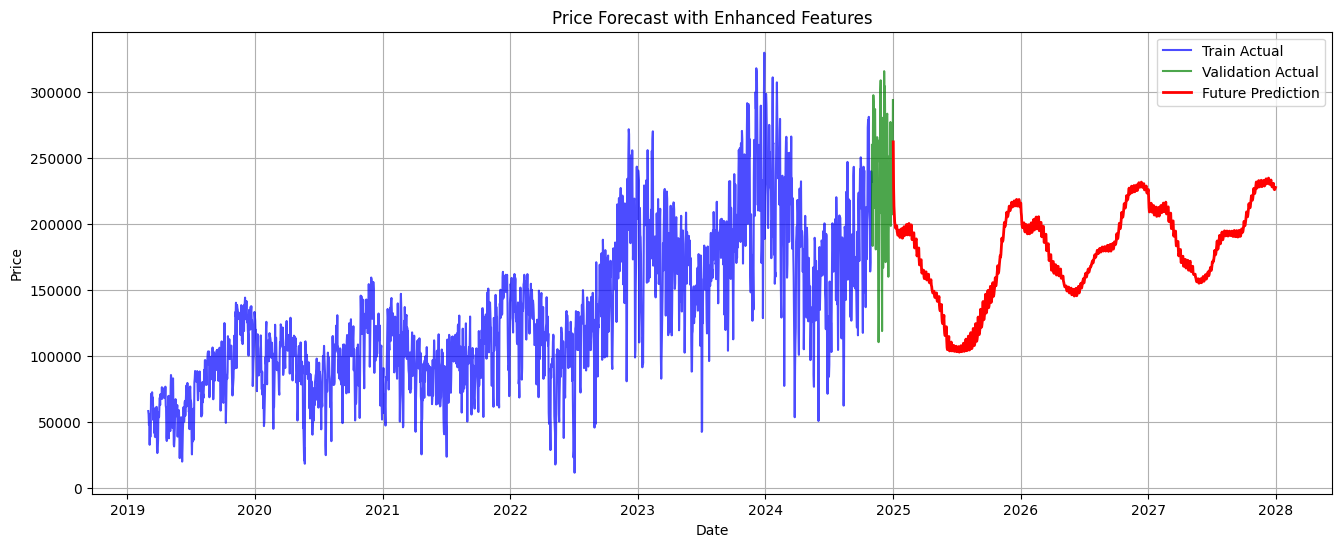

Prediction range: 102772-262261 MW
Seasonal variation: 89.1%


In [32]:
plt.figure(figsize=(16,6))

# Plot training actual
plt.plot(train['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(train_y_scaled[look_back:]), 
         label='Train Actual', color='blue', alpha=0.7)

# Plot validation actual
plt.plot(val['ds'].iloc[look_back:], 
         y_scaler.inverse_transform(val_y_scaled[look_back:]), 
         label='Validation Actual', color='green', alpha=0.7)

# Plot predictions with seasonal pattern
plt.plot(test_future['ds'], future_pred, 
         label='Future Prediction', color='red', linewidth=2)

plt.title('Price Forecast with Enhanced Features')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

print(f"Prediction range: {future_pred.min():.0f}-{future_pred.max():.0f} MW")
print(f"Seasonal variation: {(future_pred.max() - future_pred.min())/future_pred.mean()*100:.1f}%")

In [31]:
from scipy.stats import ttest_ind

# Prepare DataFrame
n_days = len(future_pred)
dates = pd.date_range('2025-01-01', periods=n_days)

pred_df = pd.DataFrame({'ds': dates, 'y_pred': future_pred})
pred_df['year'] = pred_df['ds'].dt.year
daily_rrp['year'] = daily_rrp['ds'].dt.year

# Set up
results = []

for current_year in [2025, 2026, 2027]:
    # Historical data
    historical = daily_rrp[daily_rrp['year'] < current_year]['y']
    if current_year > 2025:
        previous_year_pred = pred_df[pred_df['year'] == (current_year - 1)]['y_pred']
        historical = pd.concat([historical, previous_year_pred], ignore_index=True)
    
    # Current year data
    current = pred_df[pred_df['year'] == current_year]['y_pred']
    
    # T-test
    t_stat, p_value = ttest_ind(current, historical, equal_var=False)
    
    # Means
    historical_mean = historical.mean()
    current_mean = current.mean()
    
    # Absolute and percentage change
    mean_diff = current_mean - historical_mean
    pct_change = (mean_diff / historical_mean) * 100
    
    results.append({
        'Year': current_year,
        'Historical Mean (MW)': historical_mean,
        'Current Mean (MW)': current_mean,
        'Mean Difference (MW)': mean_diff,
        'Percentage Change (%)': pct_change,
        'T-Statistic': t_stat,
        'P-Value': p_value
    })

# Show results
results_df = pd.DataFrame(results)
print(results_df)

# Interpret results
for idx, row in results_df.iterrows():
    if row['P-Value'] < 0.05:
        print(f"✅ {row['Year']}: Significant INCREASE ({row['Percentage Change (%)']:.2f}% increase, p={row['P-Value']:.4f})")
    else:
        print(f"❌ {row['Year']}: No significant change (p={row['P-Value']:.4f})")

   Year  Historical Mean (MW)  Current Mean (MW)  Mean Difference (MW)  \
0  2025         129791.088269      155881.093750          26090.005481   
1  2026         133515.317248      185927.578125          52412.260877   
2  2027         137804.315433      195489.359375          57685.043942   

   Percentage Change (%)  T-Statistic        P-Value  
0              20.101538    10.996444   4.994032e-26  
1              39.255616    30.183153  1.144148e-143  
2              41.860114    34.031212  4.584744e-177  
✅ 2025.0: Significant INCREASE (20.10% increase, p=0.0000)
✅ 2026.0: Significant INCREASE (39.26% increase, p=0.0000)
✅ 2027.0: Significant INCREASE (41.86% increase, p=0.0000)


In [40]:
from scipy.stats import ttest_ind

# Prepare DataFrame
n_days = len(future_pred)
dates = pd.date_range('2025-01-01', periods=n_days)

pred_df = pd.DataFrame({'ds': dates, 'y_pred': future_pred})
pred_df['year'] = pred_df['ds'].dt.year
daily_rrp['year'] = daily_rrp['ds'].dt.year

# Set up
results = []

for current_year in [2025, 2026, 2027]:
    # Historical data
    historical = daily_rrp[daily_rrp['year'] < current_year]['y']
    
    # Current year data
    current = pred_df[pred_df['year'] == current_year]['y_pred']
    
    # T-test
    t_stat, p_value = ttest_ind(current, historical, equal_var=False)
    
    # Means
    historical_mean = historical.mean()
    current_mean = current.mean()
    
    # Absolute and percentage change
    mean_diff = current_mean - historical_mean
    pct_change = (mean_diff / historical_mean) * 100
    
    results.append({
        'Year': current_year,
        'Historical Mean (MW)': historical_mean,
        'Current Mean (MW)': current_mean,
        'Mean Difference (MW)': mean_diff,
        'Percentage Change (%)': pct_change,
        'T-Statistic': t_stat,
        'P-Value': p_value
    })

# Show results
results_df = pd.DataFrame(results)
print(results_df)

# Interpret results
for idx, row in results_df.iterrows():
    if row['P-Value'] < 0.05:
        print(f"✅ {row['Year']}: Significant INCREASE ({row['Percentage Change (%)']:.2f}% increase, p={row['P-Value']:.4f})")
    else:
        print(f"❌ {row['Year']}: No significant change (p={row['P-Value']:.4f})")

   Year  Historical Mean (MW)  Current Mean (MW)  Mean Difference (MW)  \
0  2025         129791.088269      155881.093750          26090.005481   
1  2026         129791.088269      185927.578125          56136.489856   
2  2027         129791.088269      195489.359375          65698.271106   

   Percentage Change (%)  T-Statistic        P-Value  
0              20.101538    10.996444   4.994032e-26  
1              43.251421    30.797024  3.442162e-153  
2              50.618476    37.259671  6.210300e-207  
✅ 2025.0: Significant INCREASE (20.10% increase, p=0.0000)
✅ 2026.0: Significant INCREASE (43.25% increase, p=0.0000)
✅ 2027.0: Significant INCREASE (50.62% increase, p=0.0000)


In [41]:
from scipy.stats import ttest_ind

# Prepare DataFrame
n_days = len(future_pred)
dates = pd.date_range('2025-01-01', periods=n_days)

pred_df = pd.DataFrame({'ds': dates, 'y_pred': future_pred})
pred_df['year'] = pred_df['ds'].dt.year
daily_rrp['year'] = daily_rrp['ds'].dt.year

# Combine 2025-2027 data (from pred_df)
combined_2025_2027 = pred_df[pred_df['year'].isin([2025, 2026, 2027])]['y_pred']

# Combine 2019-2024 data (from daily_rrp)
combined_2019_2024 = daily_rrp[daily_rrp['year'].isin([2019, 2020, 2021, 2022, 2023, 2024])]['y']

# Calculate means for both combined data sets
combined_2019_2024_mean = combined_2019_2024.mean()
combined_2025_2027_mean = combined_2025_2027.mean()

# Perform t-test between combined years 2025-2027 and 2019-2024
t_stat, p_value = ttest_ind(combined_2025_2027, combined_2019_2024, equal_var=False)

# Compute percentage change
pct_change = ((combined_2025_2027_mean - combined_2019_2024_mean) / combined_2019_2024_mean) * 100

# Show results
print(f"Combined 2019-2024 Mean: {combined_2019_2024_mean:.2f} MW")
print(f"Combined 2025-2027 Mean: {combined_2025_2027_mean:.2f} MW")
print(f"Percentage Change: {pct_change:.2f}%")

# Interpret results
if p_value < 0.05:
    print(f"✅ Significant difference detected between the combined years 2019-2024 and 2025-2027 (p={p_value:.4f}).")
else:
    print(f"❌ No significant difference detected between the combined years 2019-2024 and 2025-2027 (p={p_value:.4f}).")

Combined 2019-2024 Mean: 129791.09 MW
Combined 2025-2027 Mean: 179099.36 MW
Percentage Change: 37.99%
✅ Significant difference detected between the combined years 2019-2024 and 2025-2027 (p=0.0000).


## test for normality

2025-2027 Combined - Shapiro-Wilk Test p-value: 0.0000


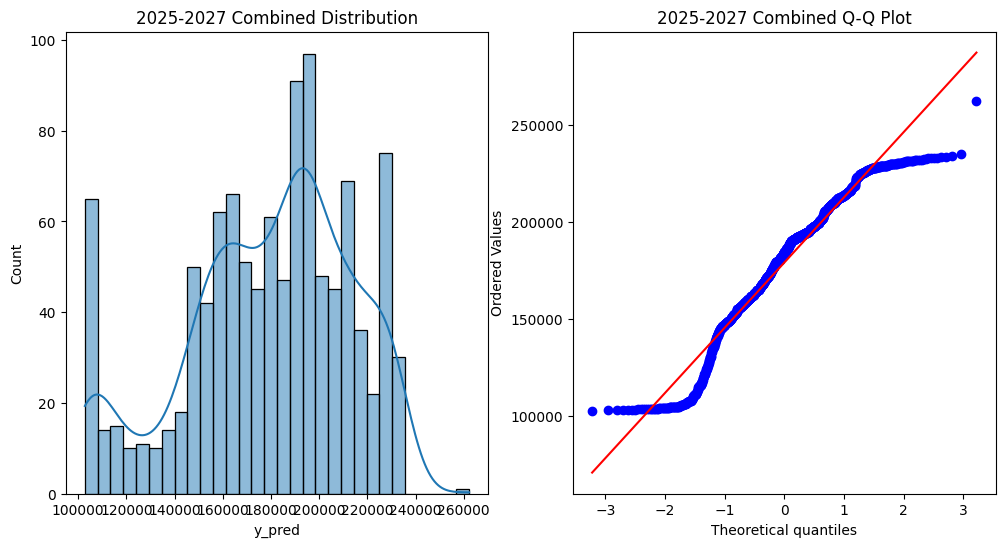

2019-2024 Combined - Shapiro-Wilk Test p-value: 0.0000


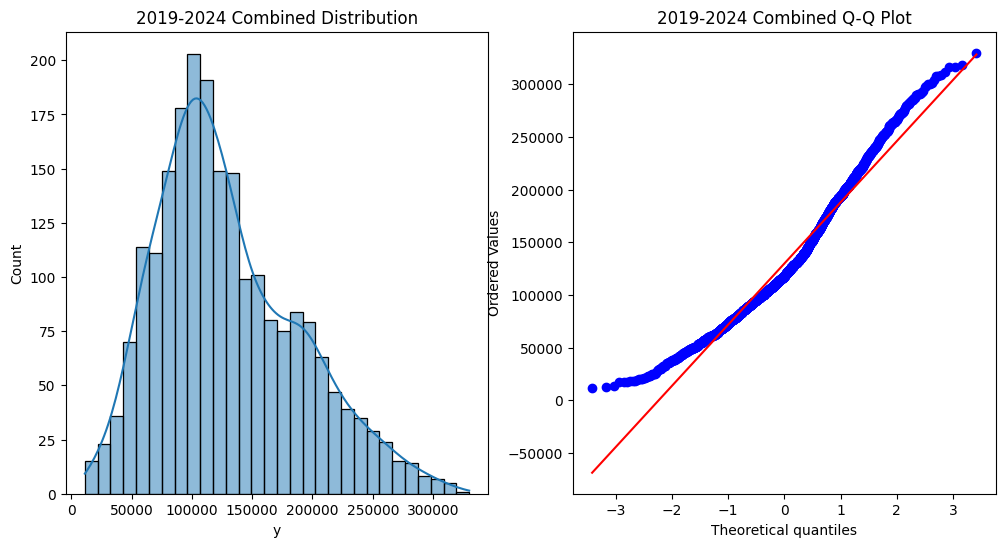

Levene's Test p-value: 0.0000
❌ One or both datasets do not follow a normal distribution.
❌ Variances are not equal (homoscedasticity assumption does not hold).


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, probplot

# Prepare DataFrame (same as before)
n_days = len(future_pred)
dates = pd.date_range('2025-01-01', periods=n_days)

pred_df = pd.DataFrame({'ds': dates, 'y_pred': future_pred})
pred_df['year'] = pred_df['ds'].dt.year
daily_rrp['year'] = daily_rrp['ds'].dt.year

# Combine 2025-2027 data (from pred_df)
combined_2025_2027 = pred_df[pred_df['year'].isin([2025, 2026, 2027])]['y_pred']

# Combine 2019-2024 data (from daily_rrp)
combined_2019_2024 = daily_rrp[daily_rrp['year'].isin([2019, 2020, 2021, 2022, 2023, 2024])]['y']

# 1. **Check Normality** for both groups using Shapiro-Wilk Test and Visualization
def check_normality(data, label):
    # Shapiro-Wilk Test
    stat, p_value = shapiro(data)
    print(f"{label} - Shapiro-Wilk Test p-value: {p_value:.4f}")
    
    # Visualizing the distribution
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(data, kde=True, bins=30)
    plt.title(f"{label} Distribution")
    
    # Q-Q Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title(f"{label} Q-Q Plot")
    
    plt.show()
    
    return p_value

# Check normality for both groups
normality_2025_2027 = check_normality(combined_2025_2027, "2025-2027 Combined")
normality_2019_2024 = check_normality(combined_2019_2024, "2019-2024 Combined")

# 2. **Check Homogeneity of Variances** using Levene's Test
stat, p_value_levene = levene(combined_2025_2027, combined_2019_2024)
print(f"Levene's Test p-value: {p_value_levene:.4f}")

# 3. **Check Independence**: Assume the data is independent in this case.

# Conclusion from Assumptions
if normality_2025_2027 > 0.05 and normality_2019_2024 > 0.05:
    print("✅ Both datasets appear to follow a normal distribution.")
else:
    print("❌ One or both datasets do not follow a normal distribution.")

if p_value_levene > 0.05:
    print("✅ Variances are equal (homoscedasticity assumption holds).")
else:
    print("❌ Variances are not equal (homoscedasticity assumption does not hold).")

# Evaluate solar generation model - transformer

## normal evaluation

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # Trend feature
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df

# Time-based split
train_end = '2023-12-31'  # First 4 years (2019-2023)
val_end = '2024-06-30'     # Next 6 months (Jan-Jun 2024)
test_end = '2024-12-31'

train = daily_rrp[daily_rrp['ds'] <= train_end]
val = daily_rrp[(daily_rrp['ds'] > train_end) & (daily_rrp['ds'] <= val_end)]
test = daily_rrp[(daily_rrp['ds'] > val_end) & (daily_rrp['ds'] <= test_end)]

# Add features
train = add_features(train)
val = add_features(val)
test = add_features(test)

# Scaling
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_y_scaled = y_scaler.transform(test[['y']])
test_features_scaled = feature_scaler.transform(test.drop(columns=['ds', 'y']))

# Create sequences
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

test_combined = np.hstack([test_y_scaled, test_features_scaled])
X_test, y_test = create_sequences(test_combined, test_y_scaled, look_back)

# Build Transformer model
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Define model
input_layer = Input(shape=(look_back, train_combined.shape[1]))
x = transformer_encoder(input_layer, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(1)(x[:, -1, :])  # Predict based on last time step

transformer_model = Model(inputs=input_layer, outputs=x)
transformer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Train model
history = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

# Evaluate on test set
test_pred = transformer_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))

Epoch 1/100
56/56 [==============================] - 2s 28ms/step - loss: 0.2297 - val_loss: 0.3328 - lr: 0.0010
Epoch 2/100
56/56 [==============================] - 1s 25ms/step - loss: 0.1698 - val_loss: 0.2835 - lr: 0.0010
Epoch 3/100
56/56 [==============================] - 1s 25ms/step - loss: 0.1455 - val_loss: 0.2946 - lr: 0.0010
Epoch 4/100
56/56 [==============================] - 1s 25ms/step - loss: 0.1507 - val_loss: 0.2692 - lr: 0.0010
Epoch 5/100
56/56 [==============================] - 1s 26ms/step - loss: 0.1422 - val_loss: 0.2705 - lr: 0.0010
Epoch 6/100
56/56 [==============================] - 1s 27ms/step - loss: 0.1408 - val_loss: 0.2784 - lr: 0.0010
Epoch 7/100
56/56 [==============================] - 2s 28ms/step - loss: 0.1423 - val_loss: 0.2650 - lr: 0.0010
Epoch 8/100
56/56 [==============================] - 1s 25ms/step - loss: 0.1395 - val_loss: 0.2738 - lr: 0.0010
Epoch 9/100
56/56 [==============================] - 1s 26ms/step - loss: 0.1381 - val_loss: 0.2

In [26]:
# Make predictions
test_pred_scaled = transformer_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_scaled = y_test.reshape(-1, 1)  # Already scaled


# Calculate both sets of metrics
metrics_original, metrics_scaled = calculate_all_metrics(
    y_test_actual, test_pred, y_test_scaled, test_pred_scaled
)

# Print results
print("\nMetrics on Original Scale:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nMetrics on Scaled Data:")
for metric, value in metrics_scaled.items():
    print(f"{metric}: {value:.4f}")

4/4 [==============================] - 0s 12ms/step

Metrics on Original Scale:
MAE: 33156.8375
MSE: 1671182590.0495
RMSE: 40880.1002
MAPE: 0.1645

Metrics on Scaled Data:
MAE: 0.5361
MSE: 0.4369
RMSE: 0.6610
MAPE: 0.8940


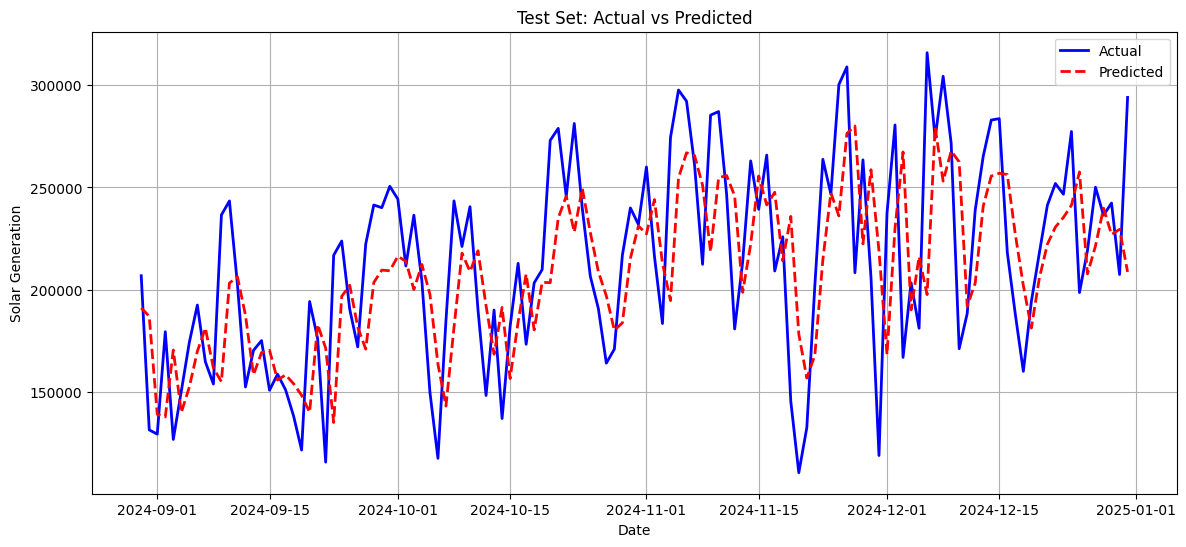

In [28]:
plt.figure(figsize=(14, 6))

# Explicitly check data lengths
min_length = min(len(test['ds'].iloc[look_back:]), len(y_test_actual), len(test_pred))
dates = test['ds'].iloc[look_back:look_back+min_length]
actuals = y_test_actual[:min_length]
preds = test_pred[:min_length]

# Plot with explicit data validation
if len(dates) > 0 and len(actuals) > 0 and len(preds) > 0:
    plt.plot(dates, actuals, label='Actual', color='blue', linewidth=2)
    plt.plot(dates, preds, label='Predicted', color='red', linestyle='--', linewidth=2)
    plt.title('Test Set: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Solar Generation')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Error: No data to plot!")
    print(f"Dates length: {len(dates)}")
    print(f"Actuals length: {len(actuals)}")
    print(f"Predictions length: {len(preds)}")

## walk forward evaluation


Walk-Forward Validation Metrics:
MAE: 33863.4533
MSE: 1719038831.1661
RMSE: 41461.2932
MAPE: 0.1699


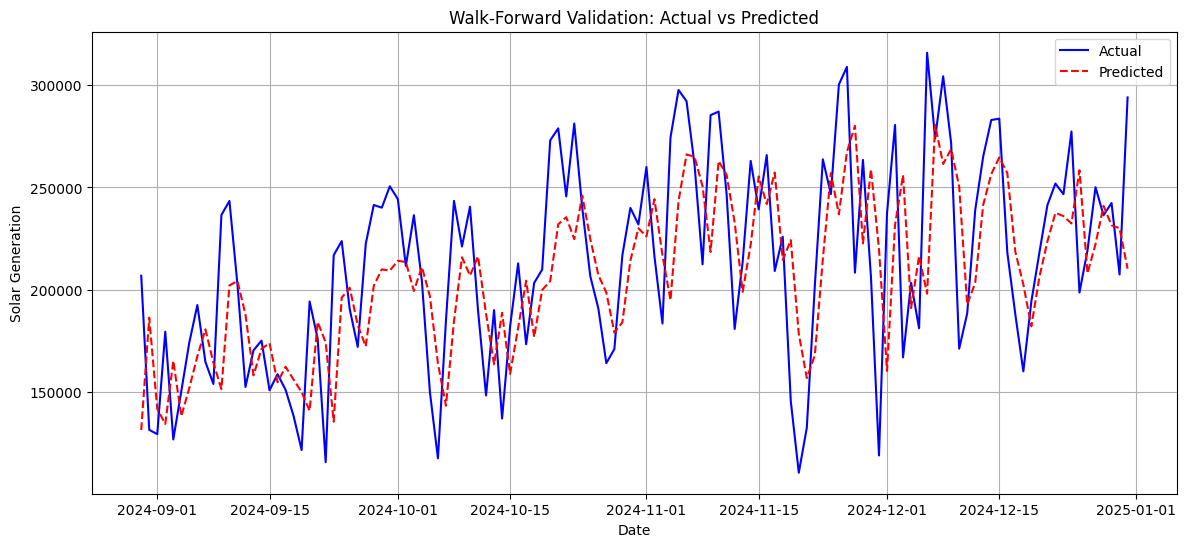


Naive Forecast Metrics:
MAE: 37343.3187
MSE: 2138832624.7086
RMSE: 46247.5148
MAPE: 0.1877

Improvement over Naive Forecast (%):
MAE: 9.32%
MSE: 19.63%
RMSE: 10.35%
MAPE: 9.51%


In [29]:
# Continue from the previous code (same data preparation and model training)

def walk_forward_validation(model, initial_sequence, X_test, y_test, look_back, steps_ahead=1):
    predictions = []
    actuals = []
    current_seq = initial_sequence.copy()
    
    for i in range(0, len(X_test), steps_ahead):
        # 1. Prepare input sequence
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        
        # 2. Make prediction
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # 3. Get actual value
        actual = y_test[i]
        actuals.append(actual)
        
        # 4. Update sequence with actual observation
        if i < len(X_test):
            # Get corresponding features for this time step
            features = X_test[i, -1, 1:]  # Assuming first column is y
            new_row = np.hstack([[actual], features])
            current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions), np.array(actuals)

# Prepare initial sequence (train + validation)
initial_sequence = np.vstack([train_combined, val_combined])

# Perform walk-forward validation
wf_pred, wf_actual = walk_forward_validation(transformer_model, initial_sequence, X_test, y_test, look_back)

# Inverse transform
wf_pred = y_scaler.inverse_transform(wf_pred.reshape(-1, 1))
wf_actual = y_scaler.inverse_transform(wf_actual.reshape(-1, 1))

# Calculate metrics
wf_metrics = calculate_metrics(wf_actual, wf_pred)
print("\nWalk-Forward Validation Metrics:")
for metric, value in wf_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:look_back+len(wf_actual)], wf_actual, label='Actual', color='blue')
plt.plot(test['ds'].iloc[look_back:look_back+len(wf_pred)], wf_pred, label='Predicted', color='red', linestyle='--')
plt.title('Walk-Forward Validation: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Solar Generation')
plt.legend()
plt.grid(True)
plt.show()

# Compare with naive forecast (persistence model)
naive_pred = np.roll(wf_actual, 1)
naive_pred[0] = wf_actual[0]  # First prediction same as first actual

naive_metrics = calculate_metrics(wf_actual, naive_pred)
print("\nNaive Forecast Metrics:")
for metric, value in naive_metrics.items():
    print(f"{metric}: {value:.4f}")

# Calculate improvement over naive
improvement = {k: (naive_metrics[k] - wf_metrics[k])/naive_metrics[k]*100 for k in wf_metrics}
print("\nImprovement over Naive Forecast (%):")
for metric, value in improvement.items():
    print(f"{metric}: {value:.2f}%")

In [32]:
print(f"\nAverage Generation: {y_test_actual.mean():.2f} MW")
print(f"MAE Relative to Mean: {metrics['MAE']/y_test_actual.mean()*100:.2f}%")
print(f"RMSE Relative to Mean: {metrics['RMSE']/y_test_actual.mean()*100:.2f}%")


Average Generation: 213056.13 MW
MAE Relative to Mean: 15.68%
RMSE Relative to Mean: 19.42%


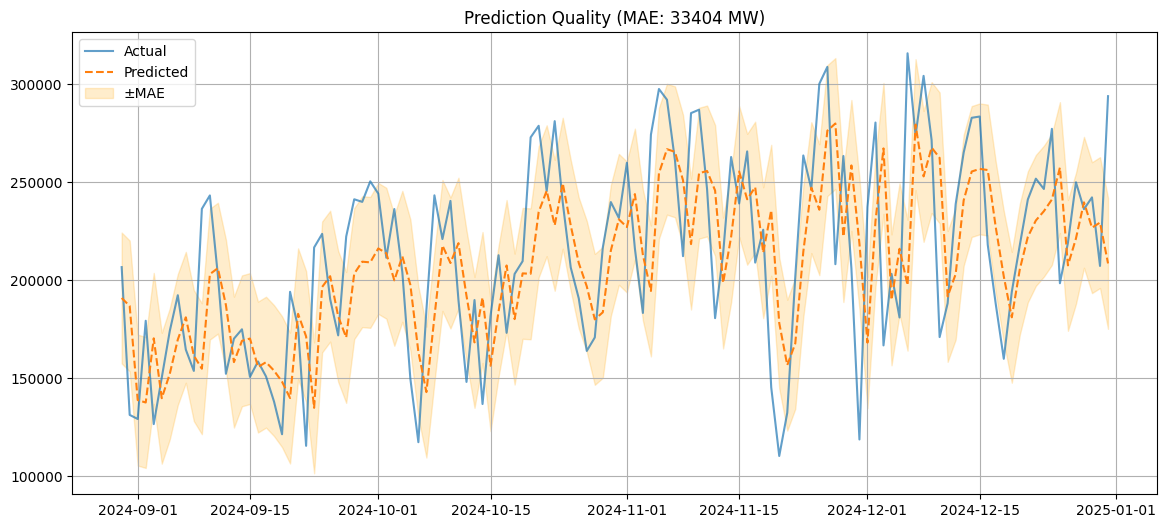

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:], y_test_actual, label='Actual', alpha=0.7)
plt.plot(test['ds'].iloc[look_back:], test_pred, label='Predicted', linestyle='--')
plt.fill_between(test['ds'].iloc[look_back:], 
                 (test_pred.flatten() - metrics['MAE']),
                 (test_pred.flatten() + metrics['MAE']),
                 color='orange', alpha=0.2, label='±MAE')
plt.title(f'Prediction Quality (MAE: {metrics["MAE"]:.0f} MW)')
plt.legend()
plt.grid()
plt.show()

# Evaluate electricity price model - transformer

## normal method

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['RRP'].mean().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # Trend feature
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df

# Time-based split
train_end = '2023-12-31'  # First 4 years (2019-2023)
val_end = '2024-06-30'     # Next 6 months (Jan-Jun 2024)
test_end = '2024-12-31'

train = daily_rrp[daily_rrp['ds'] <= train_end]
val = daily_rrp[(daily_rrp['ds'] > train_end) & (daily_rrp['ds'] <= val_end)]
test = daily_rrp[(daily_rrp['ds'] > val_end) & (daily_rrp['ds'] <= test_end)]

# Add features
train = add_features(train)
val = add_features(val)
test = add_features(test)

# Scaling
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_y_scaled = y_scaler.transform(test[['y']])
test_features_scaled = feature_scaler.transform(test.drop(columns=['ds', 'y']))

# Create sequences
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

test_combined = np.hstack([test_y_scaled, test_features_scaled])
X_test, y_test = create_sequences(test_combined, test_y_scaled, look_back)

# Build Transformer model
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Define model
input_layer = Input(shape=(look_back, train_combined.shape[1]))
x = transformer_encoder(input_layer, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(1)(x[:, -1, :])  # Predict based on last time step

transformer_model = Model(inputs=input_layer, outputs=x)
transformer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Train model
history = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

Epoch 1/100
56/56 [==============================] - 2s 27ms/step - loss: 2.4641 - val_loss: 0.8213 - lr: 0.0010
Epoch 2/100
56/56 [==============================] - 2s 27ms/step - loss: 2.3621 - val_loss: 0.2447 - lr: 0.0010
Epoch 3/100
56/56 [==============================] - 2s 28ms/step - loss: 2.2222 - val_loss: 0.3464 - lr: 0.0010
Epoch 4/100
56/56 [==============================] - 1s 27ms/step - loss: 2.2869 - val_loss: 0.3788 - lr: 0.0010
Epoch 5/100
56/56 [==============================] - 1s 26ms/step - loss: 2.1973 - val_loss: 0.2289 - lr: 0.0010
Epoch 6/100
56/56 [==============================] - 1s 25ms/step - loss: 2.1932 - val_loss: 0.2807 - lr: 0.0010
Epoch 7/100
56/56 [==============================] - 2s 27ms/step - loss: 2.1957 - val_loss: 0.2098 - lr: 0.0010
Epoch 8/100
56/56 [==============================] - 1s 27ms/step - loss: 2.1567 - val_loss: 0.2642 - lr: 0.0010
Epoch 9/100
56/56 [==============================] - 2s 29ms/step - loss: 2.1947 - val_loss: 0.3

In [24]:
# Make predictions
test_pred_scaled = transformer_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_scaled = y_test.reshape(-1, 1)  # Already scaled


# Calculate both sets of metrics
metrics_original, metrics_scaled = calculate_all_metrics(
    y_test_actual, test_pred, y_test_scaled, test_pred_scaled
)

# Print results
print("\nMetrics on Original Scale:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nMetrics on Scaled Data:")
for metric, value in metrics_scaled.items():
    print(f"{metric}: {value:.4f}")

4/4 [==============================] - 0s 12ms/step

Metrics on Original Scale:
MAE: 43.9421
MSE: 22158.3909
RMSE: 148.8569
MAPE: 0.3687

Metrics on Scaled Data:
MAE: 0.7403
MSE: 6.2886
RMSE: 2.5077
MAPE: 1.9654


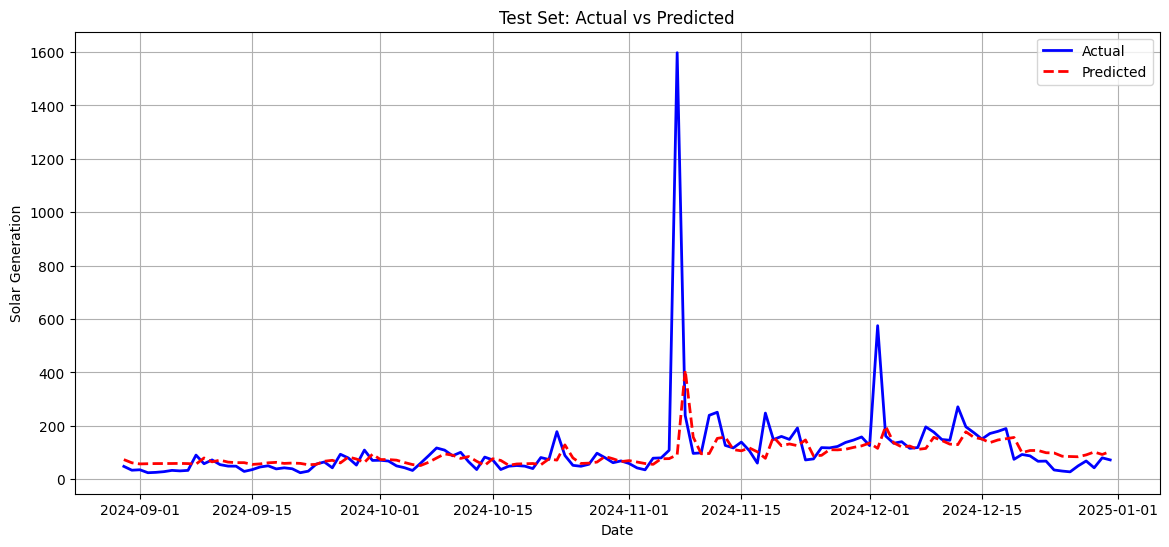

In [35]:
plt.figure(figsize=(14, 6))

# Explicitly check data lengths
min_length = min(len(test['ds'].iloc[look_back:]), len(y_test_actual), len(test_pred))
dates = test['ds'].iloc[look_back:look_back+min_length]
actuals = y_test_actual[:min_length]
preds = test_pred[:min_length]

# Plot with explicit data validation
if len(dates) > 0 and len(actuals) > 0 and len(preds) > 0:
    plt.plot(dates, actuals, label='Actual', color='blue', linewidth=2)
    plt.plot(dates, preds, label='Predicted', color='red', linestyle='--', linewidth=2)
    plt.title('Test Set: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Solar Generation')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Error: No data to plot!")
    print(f"Dates length: {len(dates)}")
    print(f"Actuals length: {len(actuals)}")
    print(f"Predictions length: {len(preds)}")

## walk forward method


Walk-Forward Validation Metrics:
MAE: 45.2122
MSE: 21762.5498
RMSE: 147.5214
MAPE: 0.4384


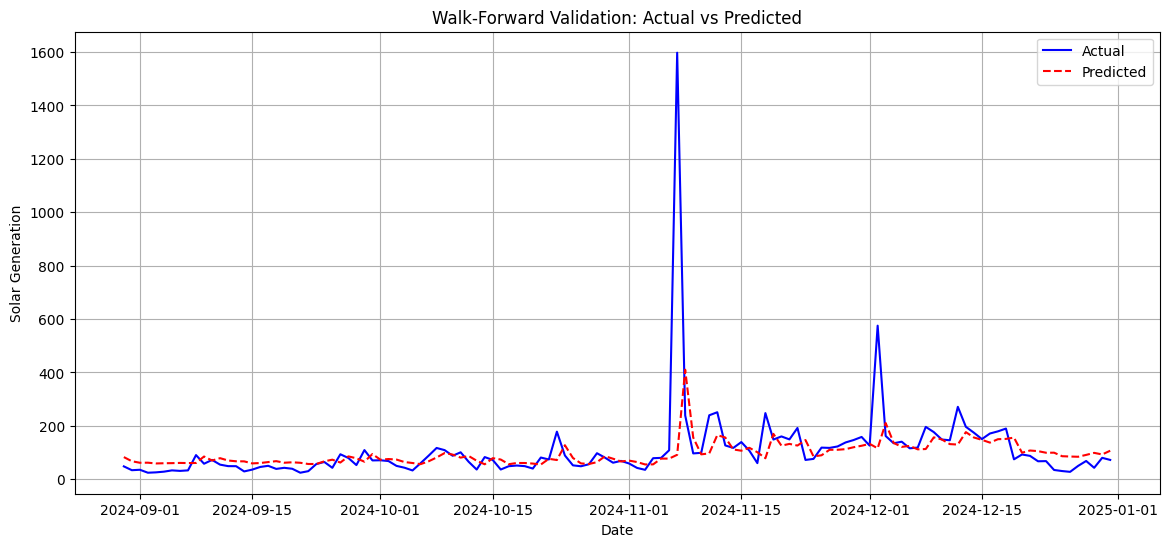


Naive Forecast Metrics:
MAE: 55.9571
MSE: 37597.3563
RMSE: 193.9004
MAPE: 0.3811

Improvement over Naive Forecast (%):
MAE: 19.20%
MSE: 42.12%
RMSE: 23.92%
MAPE: -15.05%


In [36]:
# Continue from the previous code (same data preparation and model training)

def walk_forward_validation(model, initial_sequence, X_test, y_test, look_back, steps_ahead=1):
    predictions = []
    actuals = []
    current_seq = initial_sequence.copy()
    
    for i in range(0, len(X_test), steps_ahead):
        # 1. Prepare input sequence
        x = current_seq[-look_back:].reshape(1, look_back, -1)
        
        # 2. Make prediction
        pred = model.predict(x, verbose=0)[0,0]
        predictions.append(pred)
        
        # 3. Get actual value
        actual = y_test[i]
        actuals.append(actual)
        
        # 4. Update sequence with actual observation
        if i < len(X_test):
            # Get corresponding features for this time step
            features = X_test[i, -1, 1:]  # Assuming first column is y
            new_row = np.hstack([[actual], features])
            current_seq = np.vstack([current_seq, new_row])
    
    return np.array(predictions), np.array(actuals)

# Prepare initial sequence (train + validation)
initial_sequence = np.vstack([train_combined, val_combined])

# Perform walk-forward validation
wf_pred, wf_actual = walk_forward_validation(transformer_model, initial_sequence, X_test, y_test, look_back)

# Inverse transform
wf_pred = y_scaler.inverse_transform(wf_pred.reshape(-1, 1))
wf_actual = y_scaler.inverse_transform(wf_actual.reshape(-1, 1))

# Calculate metrics
wf_metrics = calculate_metrics(wf_actual, wf_pred)
print("\nWalk-Forward Validation Metrics:")
for metric, value in wf_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:look_back+len(wf_actual)], wf_actual, label='Actual', color='blue')
plt.plot(test['ds'].iloc[look_back:look_back+len(wf_pred)], wf_pred, label='Predicted', color='red', linestyle='--')
plt.title('Walk-Forward Validation: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Solar Generation')
plt.legend()
plt.grid(True)
plt.show()

# Compare with naive forecast (persistence model)
naive_pred = np.roll(wf_actual, 1)
naive_pred[0] = wf_actual[0]  # First prediction same as first actual

naive_metrics = calculate_metrics(wf_actual, naive_pred)
print("\nNaive Forecast Metrics:")
for metric, value in naive_metrics.items():
    print(f"{metric}: {value:.4f}")

# Calculate improvement over naive
improvement = {k: (naive_metrics[k] - wf_metrics[k])/naive_metrics[k]*100 for k in wf_metrics}
print("\nImprovement over Naive Forecast (%):")
for metric, value in improvement.items():
    print(f"{metric}: {value:.2f}%")

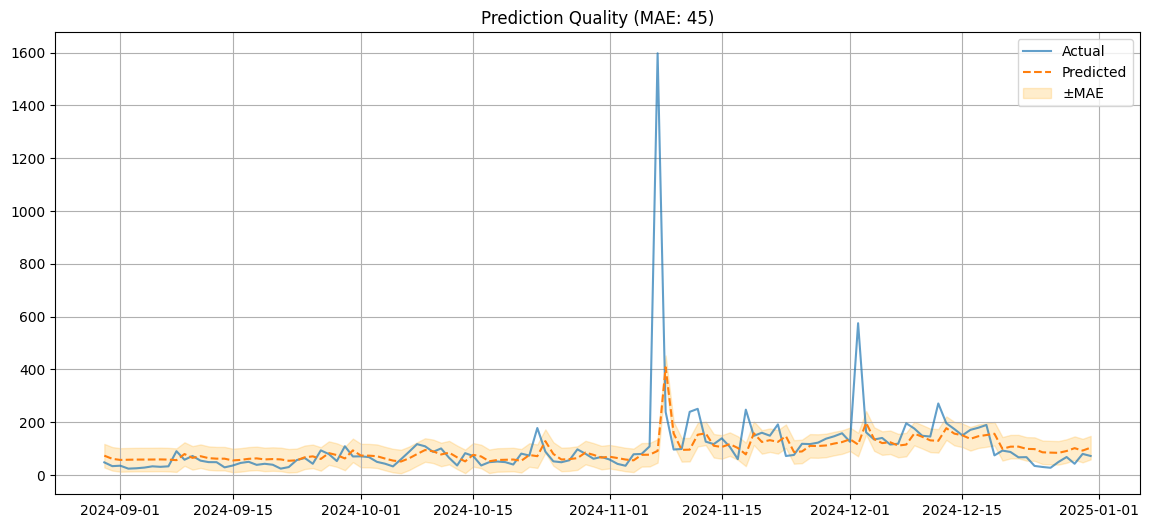

In [38]:
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:], y_test_actual, label='Actual', alpha=0.7)
plt.plot(test['ds'].iloc[look_back:], test_pred, label='Predicted', linestyle='--')
plt.fill_between(test['ds'].iloc[look_back:], 
                 (test_pred.flatten() - metrics['MAE']),
                 (test_pred.flatten() + metrics['MAE']),
                 color='orange', alpha=0.2, label='±MAE')
plt.title(f'Prediction Quality (MAE: {metrics["MAE"]:.0f})')
plt.legend()
plt.grid()
plt.show()

# Evaluate price - Attention-LSTM

## normal method

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.layers import LSTM, Dense, Dropout, Input, LayerNormalization, Multiply, Concatenate, Permute, RepeatVector, Lambda
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from keras import backend as K

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Load and prepare data (same as before)
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['RRP'].mean().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering (same as before)
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # Trend feature
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df

# Time-based split (same as before)
train_end = '2023-12-31'  # First 4 years (2019-2023)
val_end = '2024-06-30'     # Next 6 months (Jan-Jun 2024)
test_end = '2024-12-31'

train = daily_rrp[daily_rrp['ds'] <= train_end]
val = daily_rrp[(daily_rrp['ds'] > train_end) & (daily_rrp['ds'] <= val_end)]
test = daily_rrp[(daily_rrp['ds'] > val_end) & (daily_rrp['ds'] <= test_end)]

# Add features (same as before)
train = add_features(train)
val = add_features(val)
test = add_features(test)

# Scaling (same as before)
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_y_scaled = y_scaler.transform(test[['y']])
test_features_scaled = feature_scaler.transform(test.drop(columns=['ds', 'y']))

# Create sequences (same as before)
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

test_combined = np.hstack([test_y_scaled, test_features_scaled])
X_test, y_test = create_sequences(test_combined, test_y_scaled, look_back)

In [12]:
from keras.layers import LSTM, Dense, Dropout, Input, LayerNormalization, Multiply, Concatenate, Permute, RepeatVector, Lambda, Reshape
# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Corrected Attention Mechanism
def attention_block(inputs):
    # inputs shape: (batch_size, time_steps, features)
    time_steps = K.int_shape(inputs)[1]
    feature_dim = K.int_shape(inputs)[2]
    
    # Compute attention scores
    a = Dense(feature_dim, activation='tanh')(inputs)  # (batch_size, time_steps, feature_dim)
    a = Dense(1, activation='relu')(a)  # (batch_size, time_steps, 1)
    a = Reshape((time_steps,))(a)  # (batch_size, time_steps)
    a = tf.keras.layers.Activation('softmax')(a)  # (batch_size, time_steps)
    a = RepeatVector(feature_dim)(a)  # (batch_size, feature_dim, time_steps)
    a = Permute((2, 1))(a)  # (batch_size, time_steps, feature_dim)
    
    # Apply attention weights
    output_attention = Multiply()([inputs, a])
    return output_attention

# Build Attention-LSTM model
def build_attention_lstm(input_shape):
    inputs = Input(shape=input_shape)
    
    # First LSTM layer
    lstm_out = LSTM(128, return_sequences=True)(inputs)
    lstm_out = LayerNormalization()(lstm_out)
    lstm_out = Dropout(0.2)(lstm_out)
    
    # Attention mechanism
    attention_out = attention_block(lstm_out)
    
    # Second LSTM layer
    lstm_out2 = LSTM(64, return_sequences=False)(attention_out)
    lstm_out2 = LayerNormalization()(lstm_out2)
    lstm_out2 = Dropout(0.2)(lstm_out2)
    
    # Dense layers
    dense_out = Dense(64, activation='relu')(lstm_out2)
    dense_out = Dense(32, activation='relu')(dense_out)
    output = Dense(1)(dense_out)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# Create model
attention_lstm_model = build_attention_lstm((look_back, train_combined.shape[1]))
attention_lstm_model.summary()

# Train model
history = attention_lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 60, 13)]             0         []                            
                                                                                                  
 lstm_3 (LSTM)               (None, 60, 128)              72704     ['input_4[0][0]']             
                                                                                                  
 layer_normalization_3 (Lay  (None, 60, 128)              256       ['lstm_3[0][0]']              
 erNormalization)                                                                                 
                                                                                                  
 dropout_3 (Dropout)         (None, 60, 128)              0         ['layer_normalization_3[0]

4/4 [==============================] - 0s 12ms/step

Metrics on Original Scale:
MAE: 47.3791
MSE: 22655.4866
RMSE: 150.5174
MAPE: 0.3532

Metrics on Scaled Data:
MAE: 0.7982
MSE: 6.4297
RMSE: 2.5357
MAPE: 1.7906


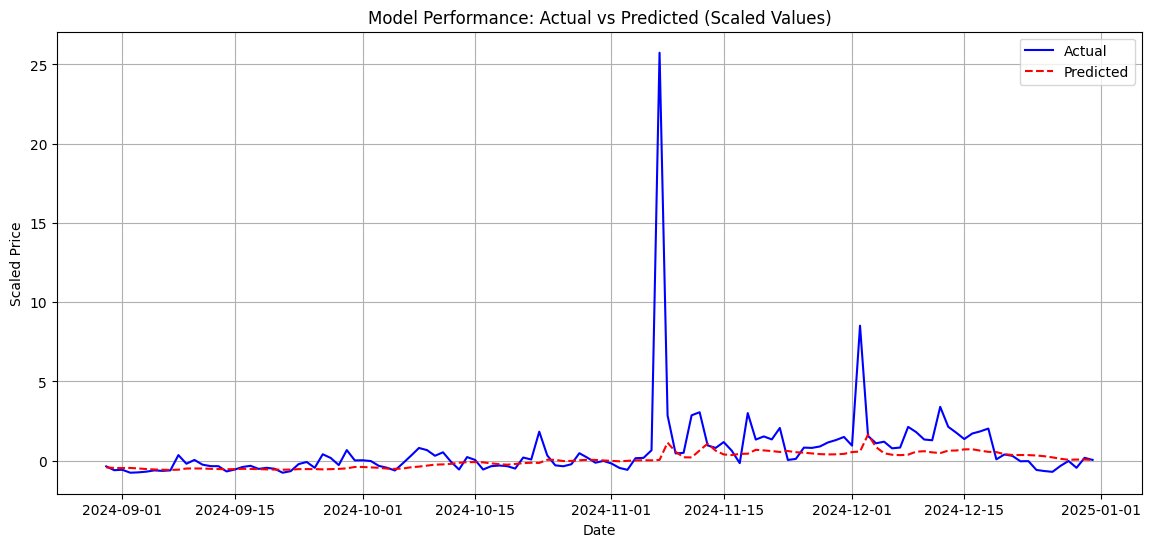

In [15]:
# Make predictions
test_pred_scaled = attention_lstm_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_scaled = y_test.reshape(-1, 1)  # Already scaled

# Calculate metrics for both scaled and unscaled data
def calculate_all_metrics(y_true, y_pred, y_true_scaled, y_pred_scaled):
    # Metrics on original scale
    metrics_original = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }
    
    # Metrics on scaled data
    metrics_scaled = {
        'MAE': mean_absolute_error(y_true_scaled, y_pred_scaled),
        'MSE': mean_squared_error(y_true_scaled, y_pred_scaled),
        'RMSE': np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled)),
        'MAPE': mean_absolute_percentage_error(y_true_scaled, y_pred_scaled)
    }
    
    return metrics_original, metrics_scaled

# Calculate both sets of metrics
metrics_original, metrics_scaled = calculate_all_metrics(
    y_test_actual, test_pred, y_test_scaled, test_pred_scaled
)

# Print results
print("\nMetrics on Original Scale:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nMetrics on Scaled Data:")
for metric, value in metrics_scaled.items():
    print(f"{metric}: {value:.4f}")

# Plot results (using scaled values only)
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:look_back+len(y_test_scaled)], 
         y_test_scaled, 
         label='Actual', 
         color='blue')
plt.plot(test['ds'].iloc[look_back:look_back+len(test_pred_scaled)], 
         test_pred_scaled, 
         label='Predicted', 
         color='red', 
         linestyle='--')
plt.title('Model Performance: Actual vs Predicted (Scaled Values)')
plt.xlabel('Date')
plt.ylabel('Scaled Price')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate solar - Attention-LSTM

In [31]:
# Load and prepare data
df_daily = df_scada_price_qld.copy()
df_daily['Date'] = pd.to_datetime(df_daily['Date_Hour']).dt.date
daily_rrp = df_daily.groupby('Date')['Solar_Generation'].sum().reset_index()
daily_rrp.columns = ['ds', 'y']
daily_rrp['ds'] = pd.to_datetime(daily_rrp['ds'])
daily_rrp = daily_rrp.set_index('ds').asfreq('D').reset_index()

# Enhanced feature engineering
def add_features(df):
    df = df.copy()
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_year'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    df['week_of_year'] = df['ds'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    
    # Fourier terms for seasonality
    for i in [1, 2, 3]:
        df[f'fourier_sin_{i}'] = np.sin(2 * i * np.pi * df['day_of_year']/365)
        df[f'fourier_cos_{i}'] = np.cos(2 * i * np.pi * df['day_of_year']/365)

    # Trend feature
    df['time_idx'] = np.arange(len(df)) / len(df)

    return df

# Time-based split
train_end = '2023-12-31'  # First 4 years (2019-2023)
val_end = '2024-06-30'     # Next 6 months (Jan-Jun 2024)
test_end = '2024-12-31'

train = daily_rrp[daily_rrp['ds'] <= train_end]
val = daily_rrp[(daily_rrp['ds'] > train_end) & (daily_rrp['ds'] <= val_end)]
test = daily_rrp[(daily_rrp['ds'] > val_end) & (daily_rrp['ds'] <= test_end)]

# Add features
train = add_features(train)
val = add_features(val)
test = add_features(test)

# Scaling
y_scaler = RobustScaler()
feature_scaler = MinMaxScaler()

# Fit on training data
train_y_scaled = y_scaler.fit_transform(train[['y']])
train_features_scaled = feature_scaler.fit_transform(train.drop(columns=['ds', 'y']))

# Scale validation and test
val_y_scaled = y_scaler.transform(val[['y']])
val_features_scaled = feature_scaler.transform(val.drop(columns=['ds', 'y']))

test_y_scaled = y_scaler.transform(test[['y']])
test_features_scaled = feature_scaler.transform(test.drop(columns=['ds', 'y']))

# Create sequences
look_back = 60

def create_sequences(features, target, look_back):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Combine features and y
train_combined = np.hstack([train_y_scaled, train_features_scaled])
X_train, y_train = create_sequences(train_combined, train_y_scaled, look_back)

val_combined = np.hstack([val_y_scaled, val_features_scaled])
X_val, y_val = create_sequences(val_combined, val_y_scaled, look_back)

test_combined = np.hstack([test_y_scaled, test_features_scaled])
X_test, y_test = create_sequences(test_combined, test_y_scaled, look_back)

## normal method

In [32]:
# Create model
attention_lstm_model = build_attention_lstm((look_back, train_combined.shape[1]))
attention_lstm_model.summary()

# Train model
history = attention_lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_12 (InputLayer)       [(None, 60, 13)]             0         []                            
                                                                                                  
 lstm_9 (LSTM)               (None, 60, 128)              72704     ['input_12[0][0]']            
                                                                                                  
 layer_normalization_29 (La  (None, 60, 128)              256       ['lstm_9[0][0]']              
 yerNormalization)                                                                                
                                                                                                  
 dropout_29 (Dropout)        (None, 60, 128)              0         ['layer_normalization_29

4/4 [==============================] - 0s 14ms/step

Metrics on Original Scale:
MAE: 32225.6238
MSE: 1698215204.3871
RMSE: 41209.4067
MAPE: 0.1690

Metrics on Scaled Data:
MAE: 0.5210
MSE: 0.4439
RMSE: 0.6663
MAPE: 1.0482


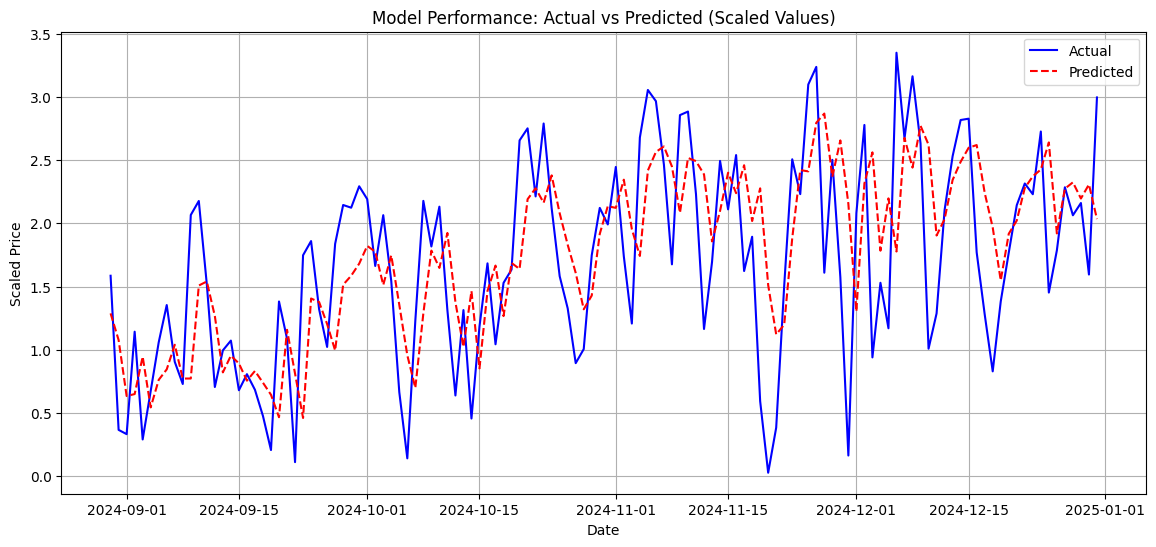

In [33]:
# Make predictions
test_pred_scaled = attention_lstm_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_scaled = y_test.reshape(-1, 1)  # Already scaled

# Calculate metrics for both scaled and unscaled data
def calculate_all_metrics(y_true, y_pred, y_true_scaled, y_pred_scaled):
    # Metrics on original scale
    metrics_original = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }
    
    # Metrics on scaled data
    metrics_scaled = {
        'MAE': mean_absolute_error(y_true_scaled, y_pred_scaled),
        'MSE': mean_squared_error(y_true_scaled, y_pred_scaled),
        'RMSE': np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled)),
        'MAPE': mean_absolute_percentage_error(y_true_scaled, y_pred_scaled)
    }
    
    return metrics_original, metrics_scaled

# Calculate both sets of metrics
metrics_original, metrics_scaled = calculate_all_metrics(
    y_test_actual, test_pred, y_test_scaled, test_pred_scaled
)

# Print results
print("\nMetrics on Original Scale:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nMetrics on Scaled Data:")
for metric, value in metrics_scaled.items():
    print(f"{metric}: {value:.4f}")

# Plot results (using scaled values only)
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:look_back+len(y_test_scaled)], 
         y_test_scaled, 
         label='Actual', 
         color='blue')
plt.plot(test['ds'].iloc[look_back:look_back+len(test_pred_scaled)], 
         test_pred_scaled, 
         label='Predicted', 
         color='red', 
         linestyle='--')
plt.title('Model Performance: Actual vs Predicted (Scaled Values)')
plt.xlabel('Date')
plt.ylabel('Scaled Price')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate price - LSTM

## normal method

In [37]:
def build_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # First LSTM layer
    lstm_out = LSTM(128, return_sequences=True)(inputs)
    lstm_out = LayerNormalization()(lstm_out)
    lstm_out = Dropout(0.2)(lstm_out)
    
    # Second LSTM layer
    lstm_out2 = LSTM(64, return_sequences=False)(lstm_out)
    lstm_out2 = LayerNormalization()(lstm_out2)
    lstm_out2 = Dropout(0.2)(lstm_out2)
    
    # Dense layers
    dense_out = Dense(64, activation='relu')(lstm_out2)
    dense_out = Dense(32, activation='relu')(dense_out)
    output = Dense(1)(dense_out)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# Create model
lstm_model = build_lstm_model((look_back, train_combined.shape[1]))
lstm_model.summary()

# Train model
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_15 (InputLayer)       [(None, 60, 13)]          0         
                                                                 
 lstm_13 (LSTM)              (None, 60, 128)           72704     
                                                                 
 layer_normalization_37 (La  (None, 60, 128)           256       
 yerNormalization)                                               
                                                                 
 dropout_37 (Dropout)        (None, 60, 128)           0         
                                                                 
 lstm_14 (LSTM)              (None, 64)                49408     
                                                                 
 layer_normalization_38 (La  (None, 64)                128       
 yerNormalization)                                        

4/4 [==============================] - 0s 14ms/step

Metrics on Original Scale:
MAE: 46.6401
MSE: 22547.6876
RMSE: 150.1589
MAPE: 0.3748

Metrics on Scaled Data:
MAE: 0.7857
MSE: 6.3991
RMSE: 2.5296
MAPE: 1.2700


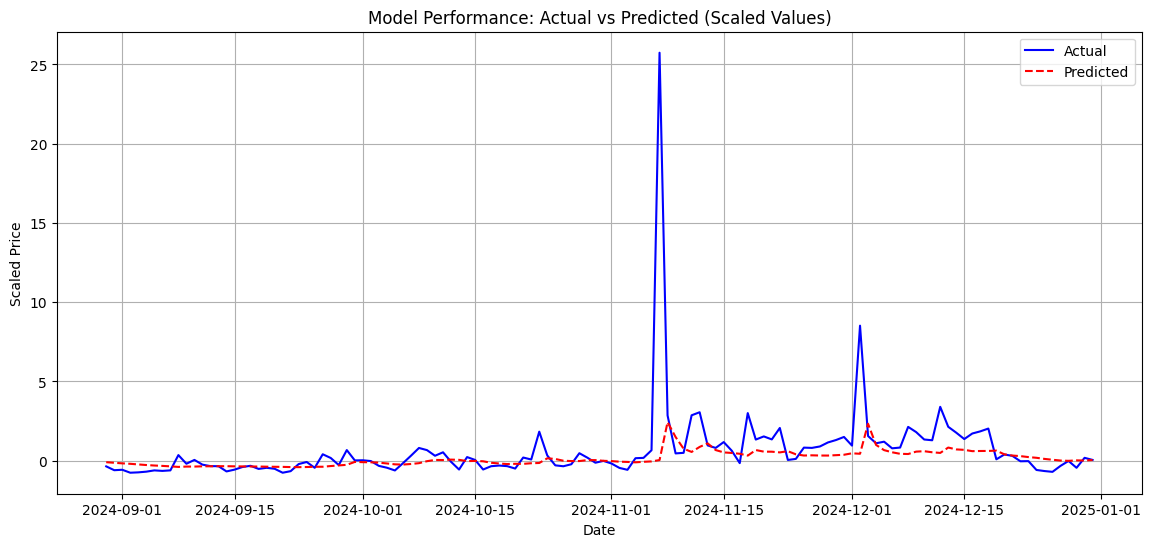

In [30]:
# Make predictions
test_pred_scaled = lstm_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_scaled = y_test.reshape(-1, 1)  # Already scaled

# Calculate metrics for both scaled and unscaled data
def calculate_all_metrics(y_true, y_pred, y_true_scaled, y_pred_scaled):
    # Metrics on original scale
    metrics_original = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }
    
    # Metrics on scaled data
    metrics_scaled = {
        'MAE': mean_absolute_error(y_true_scaled, y_pred_scaled),
        'MSE': mean_squared_error(y_true_scaled, y_pred_scaled),
        'RMSE': np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled)),
        'MAPE': mean_absolute_percentage_error(y_true_scaled, y_pred_scaled)
    }
    
    return metrics_original, metrics_scaled

# Calculate both sets of metrics
metrics_original, metrics_scaled = calculate_all_metrics(
    y_test_actual, test_pred, y_test_scaled, test_pred_scaled
)

# Print results
print("\nMetrics on Original Scale:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nMetrics on Scaled Data:")
for metric, value in metrics_scaled.items():
    print(f"{metric}: {value:.4f}")

# Plot results (using scaled values only)
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:look_back+len(y_test_scaled)], 
         y_test_scaled, 
         label='Actual', 
         color='blue')
plt.plot(test['ds'].iloc[look_back:look_back+len(test_pred_scaled)], 
         test_pred_scaled, 
         label='Predicted', 
         color='red', 
         linestyle='--')
plt.title('Model Performance: Actual vs Predicted (Scaled Values)')
plt.xlabel('Date')
plt.ylabel('Scaled Price')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate solar - LSTM

In [49]:
# Create model
lstm_model = build_lstm_model((look_back, train_combined.shape[1]))
lstm_model.summary()

# Train model
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5)
    ],
    verbose=1
)

Model: "model_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 60, 13)]          0         
                                                                 
 lstm_15 (LSTM)              (None, 60, 128)           72704     
                                                                 
 layer_normalization_43 (La  (None, 60, 128)           256       
 yerNormalization)                                               
                                                                 
 dropout_43 (Dropout)        (None, 60, 128)           0         
                                                                 
 lstm_16 (LSTM)              (None, 64)                49408     
                                                                 
 layer_normalization_44 (La  (None, 64)                128       
 yerNormalization)                                        

4/4 [==============================] - 0s 10ms/step

Metrics on Original Scale:
MAE: 32698.5687
MSE: 1624524661.2940
RMSE: 40305.3925
MAPE: 0.1664

Metrics on Scaled Data:
MAE: 0.5287
MSE: 0.4247
RMSE: 0.6517
MAPE: 0.9366


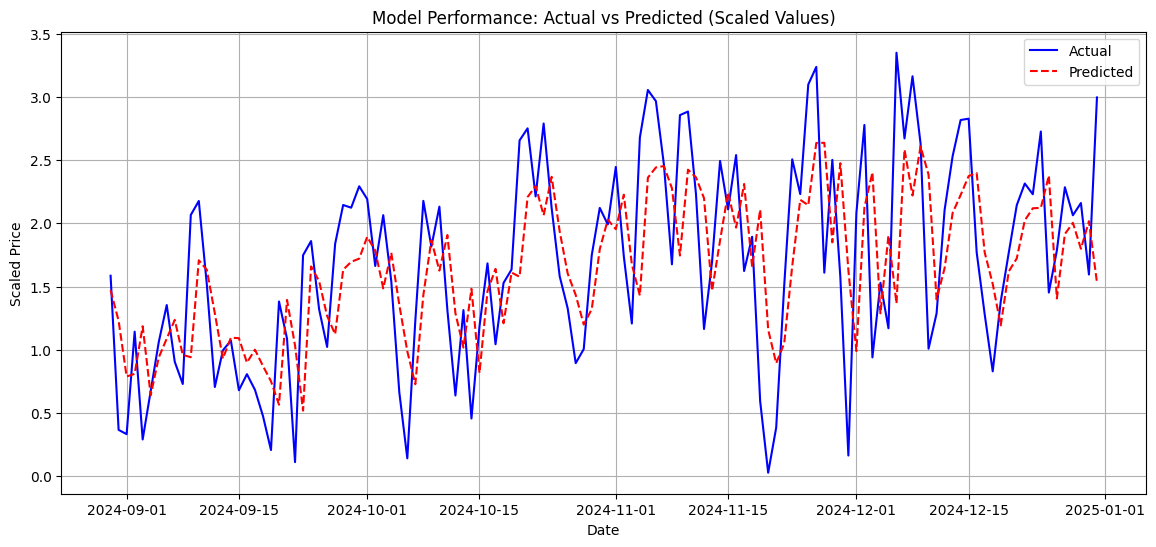

In [35]:
# Make predictions
test_pred_scaled = lstm_model.predict(X_test)
test_pred = y_scaler.inverse_transform(test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_scaled = y_test.reshape(-1, 1)  # Already scaled

# Calculate metrics for both scaled and unscaled data
def calculate_all_metrics(y_true, y_pred, y_true_scaled, y_pred_scaled):
    # Metrics on original scale
    metrics_original = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }
    
    # Metrics on scaled data
    metrics_scaled = {
        'MAE': mean_absolute_error(y_true_scaled, y_pred_scaled),
        'MSE': mean_squared_error(y_true_scaled, y_pred_scaled),
        'RMSE': np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled)),
        'MAPE': mean_absolute_percentage_error(y_true_scaled, y_pred_scaled)
    }
    
    return metrics_original, metrics_scaled

# Calculate both sets of metrics
metrics_original, metrics_scaled = calculate_all_metrics(
    y_test_actual, test_pred, y_test_scaled, test_pred_scaled
)

# Print results
print("\nMetrics on Original Scale:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nMetrics on Scaled Data:")
for metric, value in metrics_scaled.items():
    print(f"{metric}: {value:.4f}")

# Plot results (using scaled values only)
plt.figure(figsize=(14, 6))
plt.plot(test['ds'].iloc[look_back:look_back+len(y_test_scaled)], 
         y_test_scaled, 
         label='Actual', 
         color='blue')
plt.plot(test['ds'].iloc[look_back:look_back+len(test_pred_scaled)], 
         test_pred_scaled, 
         label='Predicted', 
         color='red', 
         linestyle='--')
plt.title('Model Performance: Actual vs Predicted (Scaled Values)')
plt.xlabel('Date')
plt.ylabel('Scaled Price')
plt.legend()
plt.grid(True)
plt.show()

# Mariano test (DM test) between LSTM and Transformer for price prediction

In [47]:
from scipy.stats import t

def dm_test(y_true, y_pred1, y_pred2, loss='squared'):
    if loss == 'squared':
        d = (y_true - y_pred1)**2 - (y_true - y_pred2)**2  # Pred1 worse → positive
    else:
        d = np.abs(y_true - y_pred1) - np.abs(y_true - y_pred2)
    
    dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))
    p_value = 2 * ttest_1samp(d, 0).pvalue
    return dm_stat, p_value

# Concatenate all data
full_X = np.concatenate([ X_val, X_test])
full_y = np.concatenate([y_val, y_test])

# Get predictions from both models
transformer_pred_full = transformer_model.predict(full_X).flatten()
lstm_pred_full = lstm_model.predict(full_X).flatten()

# Inverse transform if needed
full_y_actual = y_scaler.inverse_transform(full_y.reshape(-1, 1)).flatten()
transformer_pred_full = y_scaler.inverse_transform(transformer_pred_full.reshape(-1, 1)).flatten()
lstm_pred_full = y_scaler.inverse_transform(lstm_pred_full.reshape(-1, 1)).flatten()

# One-sided DM test
dm_stat, p_value = dm_test_one_sided(full_y_actual, transformer_pred_full, lstm_pred_full, loss='squared')

print(f"\nFull Dataset Evaluation:")
print(f"DM Statistic: {dm_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Transformer is significantly more accurate than LSTM on val+test data")
else:
    print("Conclusion: No significant difference on val+test data")

8/8 [==============================] - 0s 11ms/step

Full Dataset Evaluation:
DM Statistic: 1.8335
P-value: 0.0340
Conclusion: Transformer is significantly more accurate than LSTM on val+test data


# Mariano test (DM test) between LSTM and Transformer for solar generation

In [51]:
from scipy.stats import t

def dm_test_lstm_better(y_true, y_pred_lstm, y_pred_transformer, loss='no'):
    """
    One-sided DM test to check if LSTM is more accurate than Transformer.
    
    Null Hypothesis (H₀): LSTM errors >= Transformer errors (LSTM is not better)
    Alternative (H₁): LSTM errors < Transformer errors (LSTM is better)
    
    Returns:
    - dm_stat: DM test statistic (positive if LSTM is better)
    - p_value: One-sided p-value
    """
    # Calculate errors
    if loss == 'squared':
        d = (y_true - y_pred_transformer)**2 - (y_true - y_pred_lstm)**2  # Positive if LSTM is better
    else:
        d = np.abs(y_true - y_pred_transformer) - np.abs(y_true - y_pred_lstm)
    
    # DM statistic
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    n = len(d)
    dm_stat = mean_d / np.sqrt(var_d / n)
    
    # One-sided p-value (right-tail test: reject H₀ if dm_stat > 0 and p < 0.05)
    p_value = 1 - t.cdf(dm_stat, df=n-1)
    
    return dm_stat, p_value

# Concatenate validation + test data
full_X = np.concatenate([X_val, X_test])
full_y = np.concatenate([y_val, y_test])

# Get predictions
lstm_pred_full = lstm_model.predict(full_X).flatten()
transformer_pred_full = transformer_model.predict(full_X).flatten()

# Inverse transform
full_y_actual = y_scaler.inverse_transform(full_y.reshape(-1, 1)).flatten()
lstm_pred_full = y_scaler.inverse_transform(lstm_pred_full.reshape(-1, 1)).flatten()
transformer_pred_full = y_scaler.inverse_transform(transformer_pred_full.reshape(-1, 1)).flatten()

# Run the one-sided DM test (LSTM > Transformer)
dm_stat, p_value = dm_test_lstm_better(full_y_actual, lstm_pred_full, transformer_pred_full, loss='squared')

print(f"\nLSTM vs. Transformer Evaluation (Val + Test):")
print(f"DM Statistic: {dm_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05 and dm_stat > 0:
    print("Conclusion: LSTM is significantly more accurate than Transformer (p < 0.05)")
else:
    print("Conclusion: LSTM is NOT significantly more accurate than Transformer")

8/8 [==============================] - 0s 10ms/step

LSTM vs. Transformer Evaluation (Val + Test):
DM Statistic: -2.1975
P-value: 0.9855
Conclusion: LSTM is NOT significantly more accurate than Transformer
